# Diagnóstico de Câncer de Mama com Machine Learning

## Tech Challenge - Fase 1 | FIAP Pós Tech - AI for Devs

### Contexto do Problema

O câncer de mama é o tipo de câncer mais comum entre mulheres no mundo. A detecção precoce é fundamental para aumentar as chances de tratamento bem-sucedido. Neste notebook, vamos construir modelos de Machine Learning capazes de classificar tumores de mama como **malignos** ou **benignos** com base em características extraídas de imagens digitalizadas de aspiração por agulha fina (FNA) de massas mamárias.

### Dataset

Utilizaremos o **Wisconsin Breast Cancer Dataset (Diagnostic)**, obtido diretamente do Kaggle e baixado automaticamente via script (`data/download_datasets.py`). O dataset contém **569 amostras** com **30 features numéricas** extraídas de imagens de células — como raio médio, textura, perímetro, área e suavidade — agrupadas em três estatísticas por característica: média (`_media`), erro padrão (`_ep`) e pior valor (`_pior`).

### Objetivo

Treinar e comparar diferentes modelos de classificação para identificar qual apresenta o melhor desempenho no diagnóstico de câncer de mama, sempre lembrando que **o médico deve ter a palavra final** no diagnóstico.

---

## 1. Importação das Bibliotecas

Vamos começar importando as bibliotecas que serão utilizadas ao longo do notebook. Escolhemos ferramentas padrão do ecossistema Python para ciência de dados e ML.

In [125]:
# Bibliotecas para manipulação de dados
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [126]:
import pandas as pd
import numpy as np
import os

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: pré-processamento, modelos e métricas
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

# Modelos de classificação
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

# SHAP para interpretabilidade
import shap

# Importar nossas funções auxiliares
import sys
sys.path.append('..')
from src.utils import (
    plotar_distribuicao_classes, plotar_histogramas, plotar_correlacao,
    plotar_matriz_confusao, plotar_curvas_roc_comparativas,
    avaliar_modelo_cancer_mama, comparar_modelos, exibir_classification_report
)

# Configurações de visualização
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Ignorar avisos para manter o notebook limpo
import warnings
warnings.filterwarnings('ignore')

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [127]:
# Diretório para salvar os resultados (gráficos e tabelas)
DIR_RESULTADOS = os.path.join('..', 'resultados')
os.makedirs(DIR_RESULTADOS, exist_ok=True)
print(f"Gráficos serão salvos em: {os.path.abspath(DIR_RESULTADOS)}")

Gráficos serão salvos em: C:\Users\marco\PycharmProjects2\tech-challenge-1\resultados


## 2. Carregamento e Exploração dos Dados (EDA)

Vamos carregar o dataset e entender sua estrutura. É importante conhecer bem os dados antes de qualquer modelagem — isso nos ajuda a tomar decisões melhores nas etapas seguintes.

### 2.1 Carregamento do Dataset

In [128]:
# Carregar o dataset de câncer de mama a partir do CSV
# O CSV foi gerado pelo script data/download_datasets.py
# Fonte original: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data

caminho_csv = os.path.join('..', 'data', 'cancer_mama.csv')

# Se o CSV ainda não existe, rodar o script de download
if not os.path.exists(caminho_csv):
    print("CSV não encontrado. Executando script de download...")
    sys.path.append(os.path.join('..', 'data'))
    from download_datasets import baixar_cancer_mama
    baixar_cancer_mama()

# Carregar o CSV
df = pd.read_csv(caminho_csv)

# Separar nomes das features (todas as colunas exceto 'diagnosis')
feature_names = [col for col in df.columns if col != 'diagnosis']

print(f"Dataset carregado de: {caminho_csv}")
print(f"Formato do dataset: {df.shape[0]} amostras e {df.shape[1]} colunas")
print(f"\nFeatures disponíveis: {feature_names}")
print(f"\nClasses: 0 = Maligno, 1 = Benigno")
df.head()

Dataset carregado de: ..\data\cancer_mama.csv
Formato do dataset: 569 amostras e 32 colunas

Features disponíveis: ['id', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Classes: 0 = Maligno, 1 = Benigno


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 2.2 Informações Gerais do Dataset

Vamos verificar os tipos de dados, se há valores nulos e as estatísticas descritivas básicas.

In [129]:
# Informações gerais do DataFrame
print("=" * 60)
print("INFORMAÇÕES DO DATASET")
print("=" * 60)
df.info()

INFORMAÇÕES DO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  per

In [130]:
# Verificar valores nulos
print("Valores nulos por coluna:")
print(df.isnull().sum().to_string())
print(f"\nTotal de valores nulos no dataset: {df.isnull().sum().sum()}")

Valores nulos por coluna:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0

Total de valores nulos no dataset: 0


In [131]:
# Estatísticas descritivas
# Isso nos ajuda a entender a escala, a dispersão e a distribuição de cada feature
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


### 2.2.1 Conversão da Variável Alvo

A coluna `diagnosis` original possui valores categóricos:

- `M` = **Maligno**
- `B` = **Benigno**

Como os algoritmos de Machine Learning trabalham com dados numéricos, precisamos converter essa variável para formato binário.

Neste projeto foi adotada a codificação:

- `0` = Maligno
- `1` = Benigno

---

### Por que 0 = Maligno e não 1?

Em ML clínico, a convenção mais comum é usar `1` para a classe de interesse (a doença). Aqui optamos por `0 = Maligno` como uma decisão de projeto. Ambas as abordagens são válidas, mas essa escolha exige **atenção consistente** ao longo do código — principalmente ao calcular métricas e interpretar probabilidades.

> **Nota para as próximas seções:** como Maligno = 0, ao calcular métricas como Recall para a classe Maligno será necessário informar `pos_label=0` nas funções do scikit-learn. Isso ficará mais claro na seção de Avaliação dos Modelos.

---

### Contexto médico

- **Maligno**: tumor maligno, com potencial de invasão e disseminação (metástase);
- **Benigno**: tumor benigno, sem comportamento invasivo/metastático.

Essa diferença clínica é o que orienta todas as escolhas de métricas deste projeto: deixar passar um caso maligno (falso negativo) é o erro mais crítico.

In [132]:
df['diagnostico'] = df['diagnosis'].map({'M': 0, 'B': 1})
df.drop('diagnosis', axis=1, inplace=True)

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

### 2.3 Distribuição das Classes

Uma etapa importante é verificar se as classes estão balanceadas. Se houver um desbalanceamento muito grande, os modelos podem ficar enviesados para a classe majoritária, o que seria perigoso em um contexto médico — imagine um modelo que "acerta muito" mas na verdade só classifica tudo como benigno.

  -> Grafico salvo em: ..\resultados\cm_distribuicao_classes.png


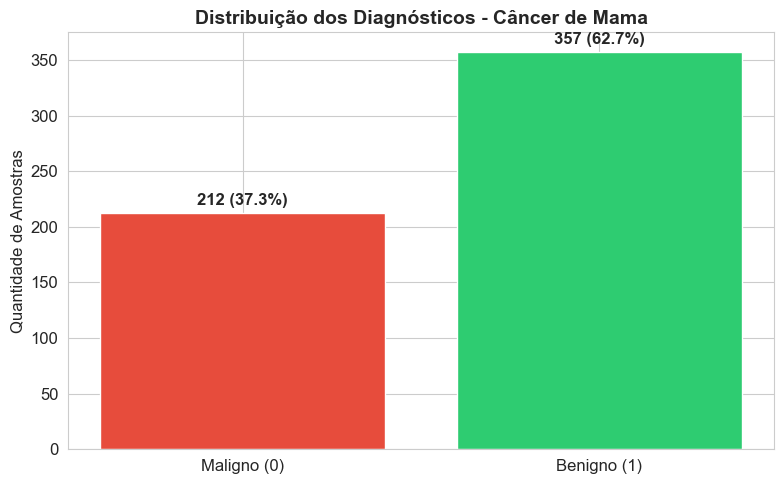

Proporção das classes:
  Maligno:  212 (37.3%)
  Benigno:  357 (62.7%)


In [134]:
# Distribuição das classes
# No dataset: 0 = maligno, 1 = benigno
plotar_distribuicao_classes(
    df['diagnostico'],
    nomes_classes=['Maligno (0)', 'Benigno (1)'],
    titulo='Distribuição dos Diagnósticos - Câncer de Mama',
    salvar_em=os.path.join(DIR_RESULTADOS, 'cm_distribuicao_classes.png')
)

# Proporção exata
print(f"Proporção das classes:")
print(f"  Maligno:  {(df['diagnostico'] == 0).sum()} ({(df['diagnostico'] == 0).mean()*100:.1f}%)")
print(f"  Benigno:  {(df['diagnostico'] == 1).sum()} ({(df['diagnostico'] == 1).mean()*100:.1f}%)")

### Análise do balanceamento das classes

O dataset apresenta uma distribuição de classes levemente desbalanceada, com aproximadamente **63% de instâncias benignas** e **37% de instâncias malignas**. Embora exista uma diferença entre as classes, esse nível de desbalanceamento não é considerado crítico.

Em termos práticos, a classe minoritária (maligna) ainda possui representatividade suficiente para que os modelos de aprendizado de máquina consigam identificar padrões relevantes sem necessidade de técnicas adicionais de balanceamento.


### Justificativa para não utilização de técnicas de balanceamento

Técnicas como o **SMOTE (Synthetic Minority Over-sampling Technique)** são geralmente recomendadas em cenários onde há desbalanceamento severo, por exemplo, quando a classe minoritária representa menos de 20% do conjunto de dados.

No presente caso, a proporção de 37% para a classe minoritária indica que:

- Há quantidade suficiente de amostras para aprendizado adequado;
- O risco de viés extremo para a classe majoritária é reduzido;
- A aplicação de técnicas de oversampling poderia introduzir **ruído artificial** e potencialmente levar ao **overfitting**, prejudicando a capacidade de generalização do modelo.

Dessa forma, optou-se por **não aplicar técnicas de balanceamento** neste momento.


### 2.4 Distribuição das Features

Nesta etapa, analisamos a distribuição das *features* (variáveis explicativas) com o objetivo de compreender melhor o comportamento dos dados e identificar possíveis padrões ou a presença de outliers.

As *features* representam as características observadas em cada registro do dataset e são utilizadas como base para a predição da variável alvo (*target*), que corresponde à informação que o modelo busca prever.

A análise da distribuição dessas variáveis permite:

- Identificar a presença de valores extremos (*outliers*), que são observações significativamente distantes do padrão geral dos dados;
- Verificar assimetrias, dispersões e possíveis inconsistências;
- Compreender melhor a relação entre as variáveis e seu impacto na predição.

Os *outliers* podem representar tanto ruídos quanto comportamentos reais do dataset, sendo importante avaliá-los com cautela antes de decidir por sua remoção ou tratamento.

Vamos fazer uma tratativa , alterando os nomes dos cabeçalhos para facilitar a visualização e interpretação dos gráficos. Por exemplo, vamos substituir "mean radius" por "Raio Médio", "mean texture" por "Textura Média", e assim por diante. Essa abordagem torna os gráficos mais acessíveis, especialmente para aqueles que não estão familiarizados com os termos técnicos em inglês.

Atenção: colunas sem tradução: {'id', 'diagnostico'}
Features de valores médios: ['raio_media', 'textura_media', 'perimetro_media', 'area_media', 'suavidade_media', 'compacidade_media', 'concavidade_media', 'pontos_concavos_media', 'simetria_media', 'dimensao_fractal_media']


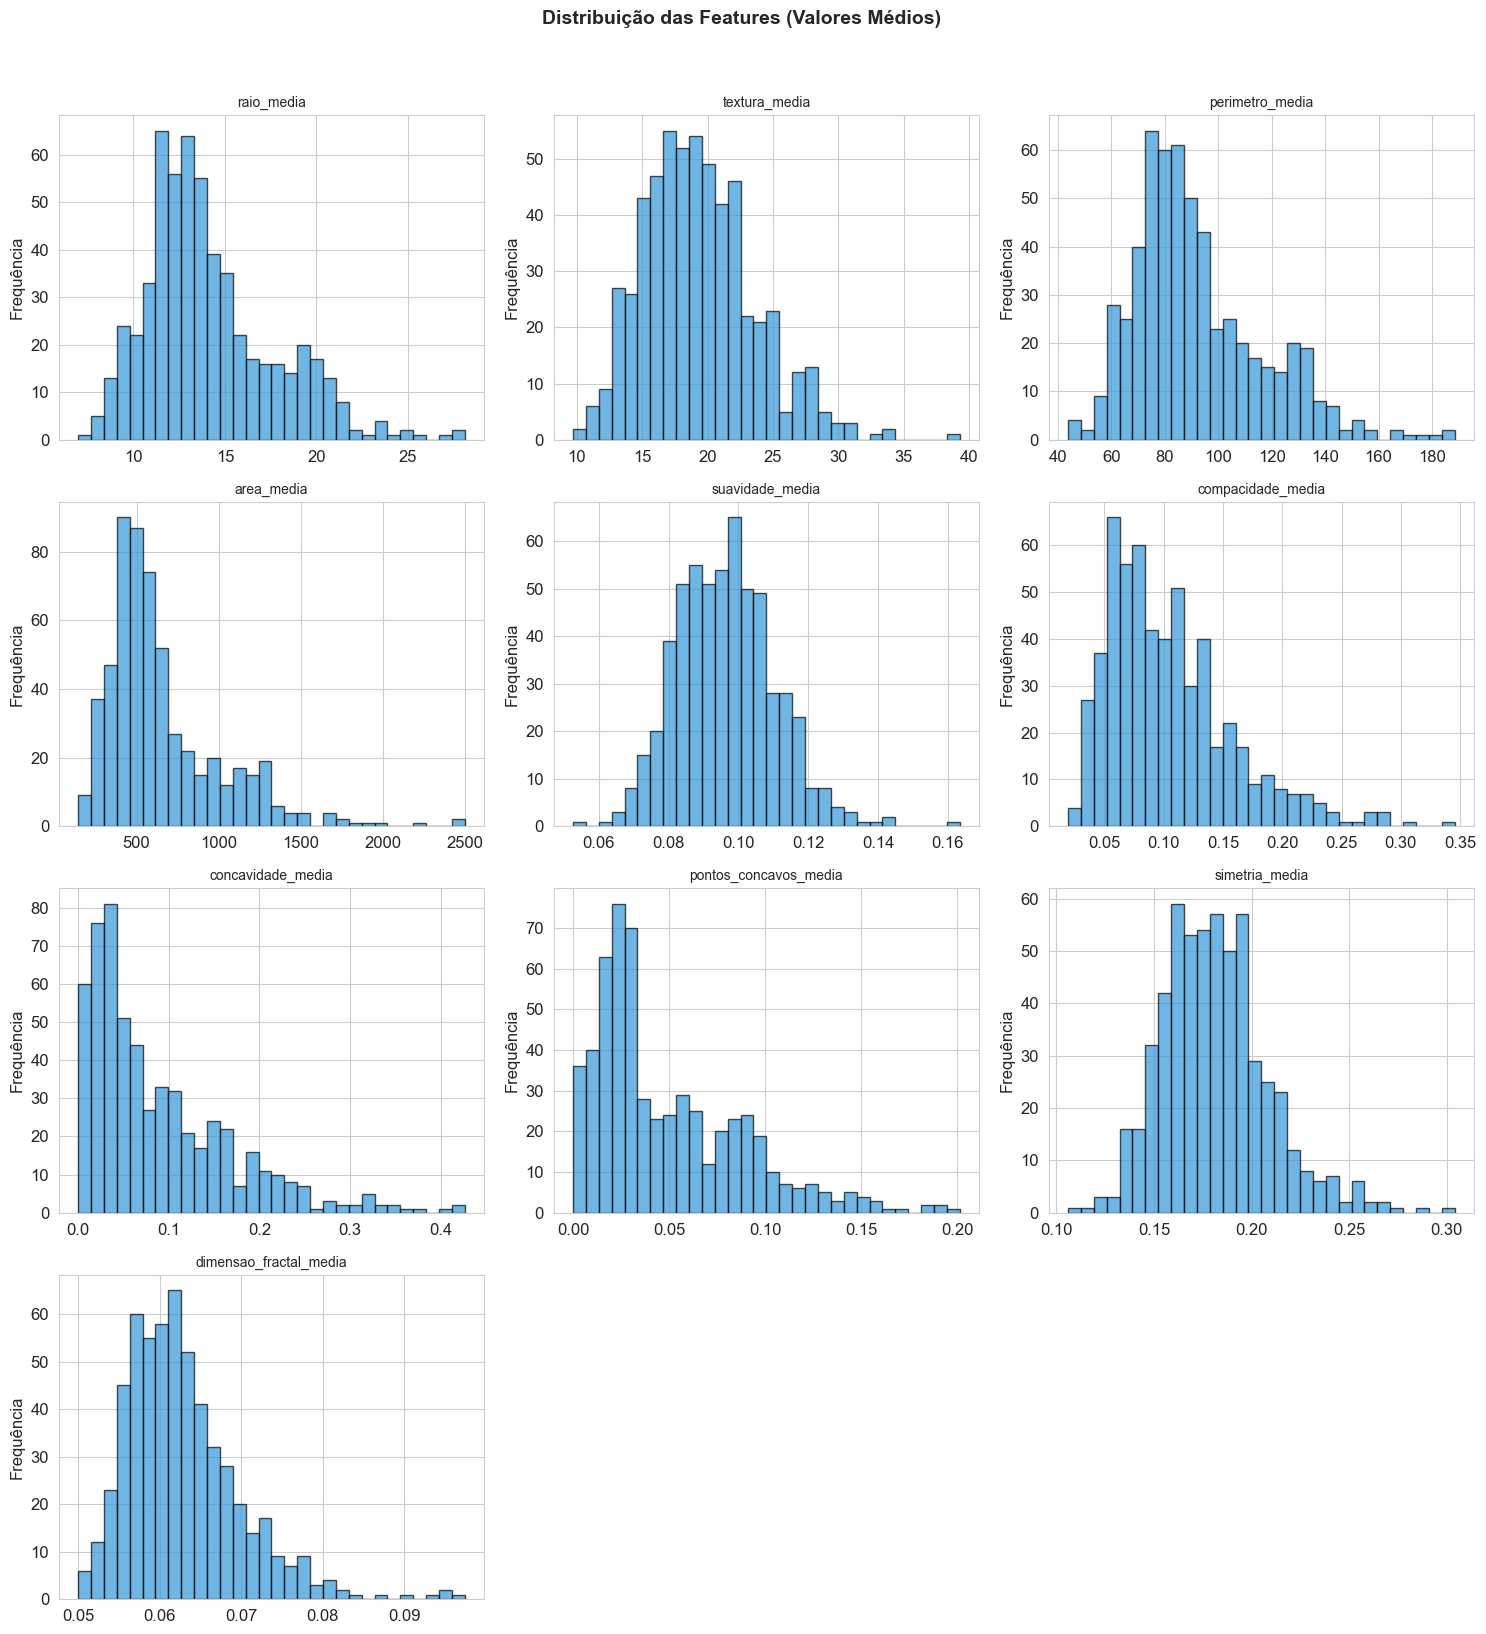

In [135]:

# Mapeamento direto: nome original -> nome traduzido
traducao_colunas = {

    # Valores médios (mean)
    'radius_mean': 'raio_media',
    'texture_mean': 'textura_media',
    'perimeter_mean': 'perimetro_media',
    'area_mean': 'area_media',
    'smoothness_mean': 'suavidade_media',
    'compactness_mean': 'compacidade_media',
    'concavity_mean': 'concavidade_media',
    'concave points_mean': 'pontos_concavos_media',
    'symmetry_mean': 'simetria_media',
    'fractal_dimension_mean': 'dimensao_fractal_media',

    # Erro padrão (se)
    'radius_se': 'raio_ep',
    'texture_se': 'textura_ep',
    'perimeter_se': 'perimetro_ep',
    'area_se': 'area_ep',
    'smoothness_se': 'suavidade_ep',
    'compactness_se': 'compacidade_ep',
    'concavity_se': 'concavidade_ep',
    'concave points_se': 'pontos_concavos_ep',
    'symmetry_se': 'simetria_ep',
    'fractal_dimension_se': 'dimensao_fractal_ep',

    # Pior valor (worst)
    'radius_worst': 'raio_pior',
    'texture_worst': 'textura_pior',
    'perimeter_worst': 'perimetro_pior',
    'area_worst': 'area_pior',
    'smoothness_worst': 'suavidade_pior',
    'compactness_worst': 'compacidade_pior',
    'concavity_worst': 'concavidade_pior',
    'concave points_worst': 'pontos_concavos_pior',
    'symmetry_worst': 'simetria_pior',
    'fractal_dimension_worst': 'dimensao_fractal_pior',
}

def traduzir_colunas(df, mapeamento=traducao_colunas):
    """
    Lê as colunas do DataFrame e traduz os cabeçalhos para português.
    Retorna um novo DataFrame com as colunas renomeadas.
    """
    # Verifica quais colunas do df estão no mapeamento (evita erros)
    colunas_para_traduzir = {k: v for k, v in mapeamento.items() if k in df.columns}

    # Avisa sobre colunas não mapeadas
    nao_mapeadas = set(df.columns) - set(colunas_para_traduzir.keys())
    if nao_mapeadas:
        print(f"Atenção: colunas sem tradução: {nao_mapeadas}")

    return df.rename(columns=colunas_para_traduzir)


# Aplica a tradução
df = traduzir_colunas(df)
feature_names = df.columns.tolist()

# Agora filtra as features de valores médios
features_mean = [col for col in feature_names if col.endswith('_media')]
print(f"Features de valores médios: {features_mean}")

plotar_histogramas(df, features_mean, titulo='Distribuição das Features (Valores Médios)')

### Análise dos histogramas

A partir da análise dos histogramas, observa-se que algumas features, como `raio_media`, `perimetro_media` e `area_media`, apresentam distribuições assimétricas à direita (right-skewed), com maior concentração de valores mais baixos e uma cauda estendida para valores mais altos. Esse comportamento sugere a presença de observações com valores elevados, que podem ser interpretadas como possíveis outliers ou variações relevantes nas dimensões dos tumores.

Por outro lado, variáveis como `suavidade_media` e `simetria_media` apresentam distribuições mais próximas da simetria, indicando uma dispersão mais homogênea e menor influência de valores extremos.

Entretanto, é importante destacar que essa análise é univariada e, portanto, não permite inferir diretamente a capacidade discriminativa das features em relação à variável alvo (benigno vs maligno). Para uma avaliação mais robusta, seria necessário analisar a distribuição dessas variáveis considerando a separação por classe, por meio de técnicas como boxplots condicionados ao target ou outras abordagens estatísticas.


### Questionamentos levantados

- As distribuições assimétricas observadas podem impactar o desempenho dos modelos de machine learning?
- Os valores extremos identificados representam ruído ou características relevantes do problema?
- Quais features tem mais capacidade de discriminar entre tumores benignos e malignos?
- As variáveis seguem uma distribuição normal e isso é relevante para os modelos escolhidos?
- Existe correlação ou redundância entre variáveis como `raio_media`, `perimetro_media` e `area_media`?

---

### Discussão inicial

As distribuições assimétricas podem influenciar o desempenho de alguns algoritmos, especialmente aqueles sensíveis à escala e à distribuição dos dados. Nesse sentido, transformações como normalização ou padronização podem ser consideradas.

Em relação aos valores extremos, é importante destacar que, em datasets da área da saúde, esses valores podem representar casos reais e relevantes, como tumores com dimensões maiores. Portanto, a remoção de outliers deve ser realizada com cautela, após análise mais aprofundada.

Além disso, a análise univariada realizada até o momento não permite avaliar diretamente o poder discriminativo das variáveis. Para isso, será necessário considerar a relação das features com a variável alvo, por meio de análises adicionais, como visualizações por classe e métricas estatísticas.

Por fim, considerando a possível relação entre algumas variáveis (como raio, perímetro e área), torna-se relevante investigar a existência de correlação entre elas, uma vez que isso pode impactar modelos sensíveis à multicolinearidade.

---

### Próximos passos

Com base nos questionamentos levantados, as próximas etapas da análise incluirão:

- Avaliação da distribuição das variáveis por classe (benigno vs maligno);
- Análise de correlação entre as features;
- Identificação do impacto de outliers no desempenho dos modelos;
- Aplicação de técnicas de pré-processamento, quando necessário;
- Avaliação do poder discriminativo das variáveis.

Essas etapas são fundamentais para garantir uma modelagem mais robusta e bem fundamentada.

### Boxplots para comparação entre classes (maligno vs. benigno)

Para analisar as diferenças entre tumores malignos e benignos, utilizamos boxplots de algumas features consideradas relevantes. Essas variáveis foram escolhidas por representarem aspectos importantes como tamanho, forma e textura dos tumores.

**1. Representatividade geométrica do tumor** — `raio_media`, `perimetro_media`, `area_media`

Essas variáveis estão diretamente relacionadas ao tamanho e à escala do tumor. Em geral, tumores malignos tendem a apresentar maiores dimensões ou crescimento mais irregular, tornando essas features altamente informativas para a diferenciação entre classes.

**2. Textura e heterogeneidade** — `textura_media`

Essa feature captura variações na intensidade dos pixels nas imagens médicas, refletindo a heterogeneidade do tecido. Tumores malignos costumam apresentar texturas mais irregulares.

**3. Regularidade da borda** — `suavidade_media`

Indica o grau de suavidade ou irregularidade do contorno do tumor. Tumores malignos geralmente possuem bordas menos regulares.

**4. Formato e compactação** — `compacidade_media`

Relaciona área e perímetro para medir o quão compacto é o tumor. Tumores benignos tendem a apresentar formas mais regulares e compactas, enquanto tumores malignos costumam ser mais irregulares e dispersos.

  -> Gráfico salvo em: ..\resultados\cm_boxplots.png


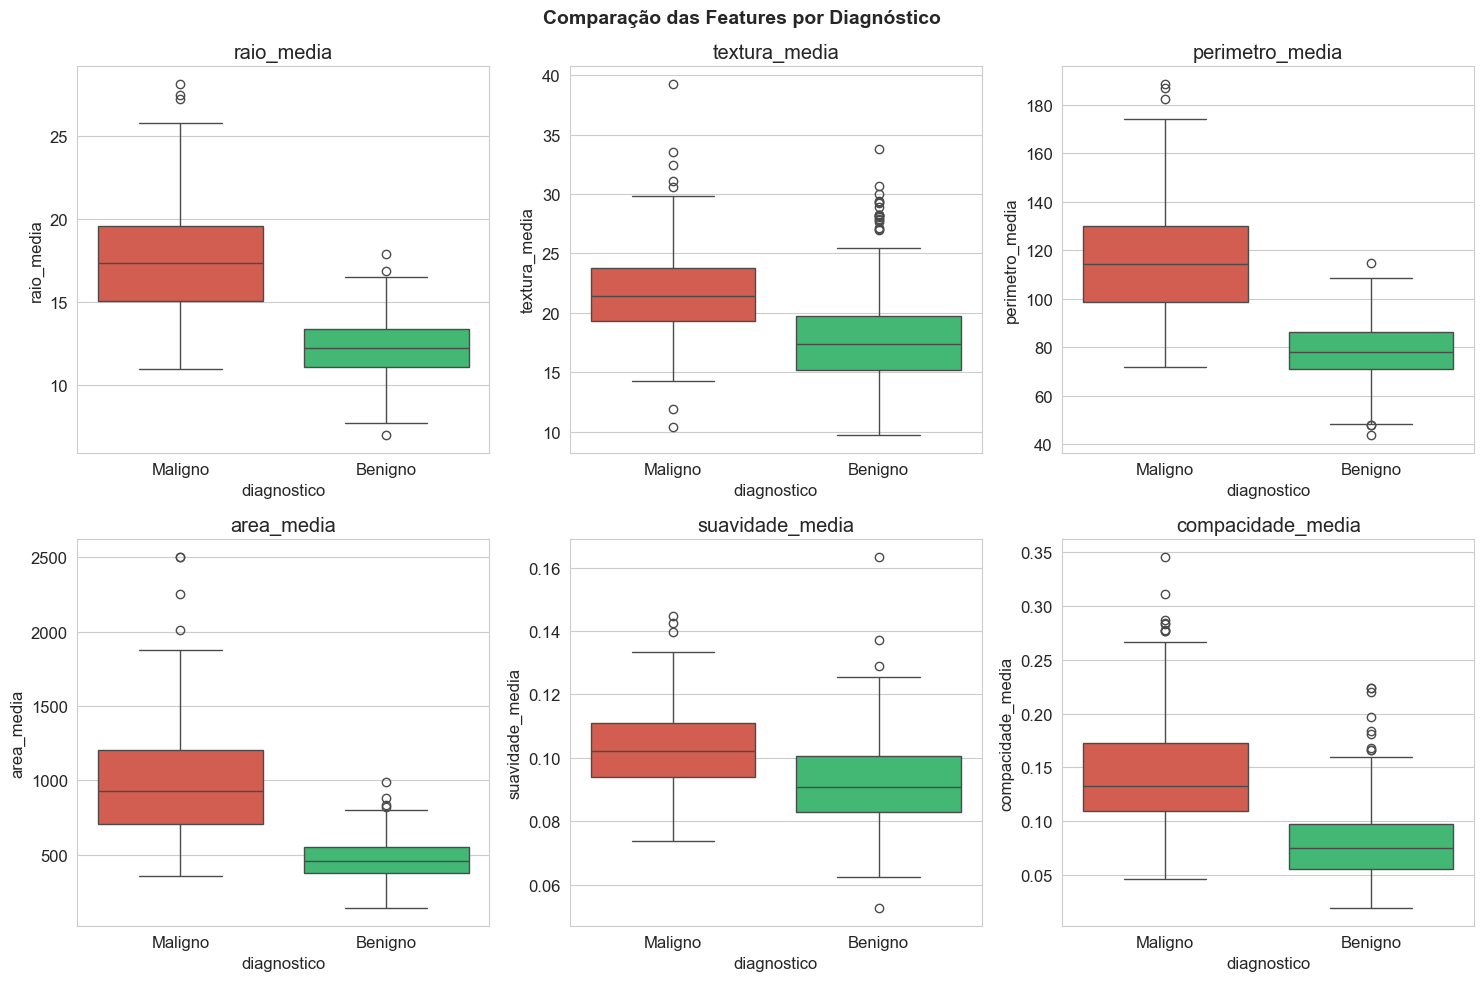

In [136]:
features_destaque = ['raio_media', 'textura_media', 'perimetro_media', 'area_media',
                     'suavidade_media', 'compacidade_media']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(features_destaque):
    sns.boxplot(data=df, x='diagnostico', y=feature, ax=axes[i],
                palette=['#e74c3c', '#2ecc71'])
    axes[i].set_xticklabels(['Maligno', 'Benigno'])
    axes[i].set_title(feature)

fig.suptitle('Comparação das Features por Diagnóstico', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(DIR_RESULTADOS, 'cm_boxplots.png'), dpi=150, bbox_inches='tight')
print(f"  -> Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'cm_boxplots.png')}")
plt.show()

### Análise dos boxplots

Observa-se que features como `raio_media`, `perimetro_media` e `area_media` apresentam uma separação bastante clara entre tumores malignos e benignos. Em geral, tumores malignos tendem a possuir valores mais elevados nessas medidas, o que é consistente do ponto de vista biológico, já que costumam crescer mais e de forma menos controlada.

Por outro lado, a feature `suavidade_media` apresenta menor capacidade de separação entre as classes, indicando que pode ter um poder discriminativo mais limitado para a tarefa de classificação.

---

## 3. Pré-processamento dos Dados

Antes do treinamento dos modelos, é fundamental preparar os dados adequadamente. Essa etapa garante melhor desempenho e maior confiabilidade nos resultados. O pré-processamento inclui:

- Separação entre variáveis preditoras (features) e variável alvo
- Análise de correlação entre as features
- Aplicação de escalonamento (feature scaling)
- Divisão dos dados em conjuntos de treino e teste

### 3.1 Análise de Correlação

Nesta etapa, analisamos a correlação entre as features para identificar possíveis relações fortes entre elas. Variáveis altamente correlacionadas podem introduzir redundância no modelo, especialmente em algoritmos mais sensíveis a esse aspecto.

Ainda assim, neste primeiro momento, optamos por manter todas as features e observar como os modelos se comportam antes de aplicar qualquer técnica de redução de dimensionalidade.

  -> Grafico salvo em: ..\resultados\cm_correlacao.png


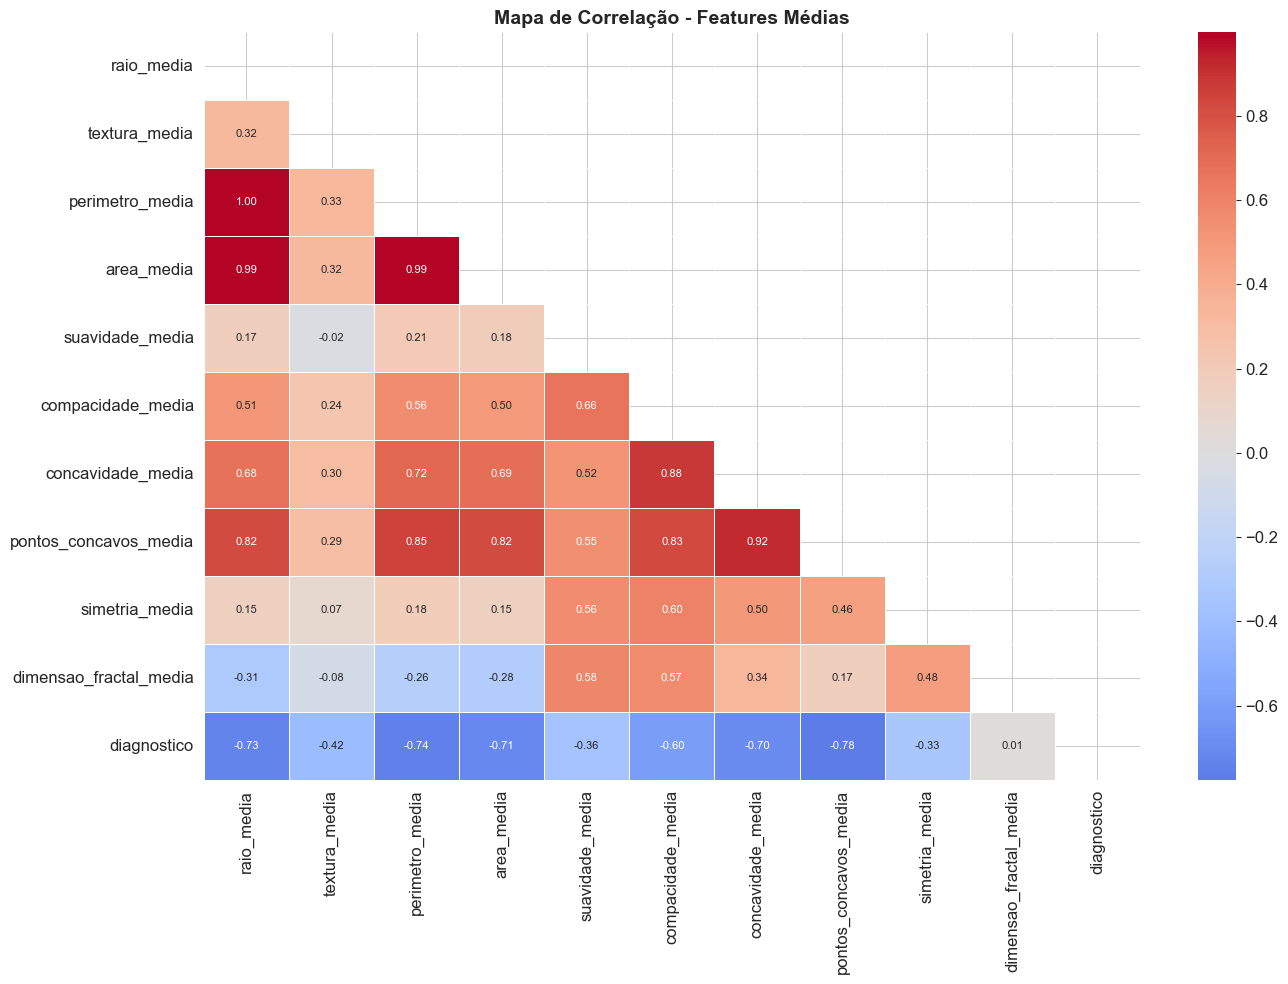

In [137]:
# Análise de correlação - vamos usar apenas as features 'mean' para o heatmap ficar legível
df_mean = df[features_mean + ['diagnostico']]
correlacao = plotar_correlacao(df_mean, titulo='Mapa de Correlação - Features Médias',
                        salvar_em=os.path.join(DIR_RESULTADOS, 'cm_correlacao.png'))

### 1. Mapa de Correlação

O mapa de correlação foi apresentado utilizando apenas metade da matriz (triângulo inferior), o que é uma prática comum em análise exploratória de dados.

Isso ocorre porque a matriz de correlação é simétrica, ou seja, a correlação entre duas variáveis é igual independentemente da ordem (por exemplo, a correlação entre raio_medio e area_media é a mesma que entre area_media e raio_medio).

Dessa forma, exibir a matriz completa resultaria em informação duplicada.

Ao mostrar apenas metade da matriz, evitamos redundância e reduzimos a poluição visual, tornando a interpretação mais clara e objetiva.

Além disso, a diagonal principal apresenta valor igual a 1, pois representa a correlação de cada variável com ela mesma.

### 2. Interpretação do Mapa de Correlação

Observa-se uma alta correlação entre variáveis geométricas, como raio_medio, perimetro_medio e area_media, já que todas estão diretamente relacionadas ao tamanho do tumor. Isso indica possível redundância entre essas variáveis.

Além disso, features como concavidade_media e pontos_concavos_media também apresentam forte correlação entre si, sugerindo que descrevem aspectos semelhantes da forma do tumor.

Em relação à variável alvo diagnostico, nota-se uma correlação negativa relevante com várias features, especialmente aquelas ligadas ao tamanho e irregularidade. Isso indica que valores mais altos nessas variáveis estão associados a tumores malignos.

Apesar dessas correlações, optamos inicialmente por manter todas as variáveis e avaliar o impacto nos modelos antes de aplicar técnicas de redução de dimensionalidade.


In [138]:
# Identificar pares de features com alta correlação (acima de 0.9)
# Isso nos ajuda a entender a redundância nos dados
correlacao_completa = df.drop('diagnostico', axis=1).corr()
pares_alta_corr = []

for i in range(len(correlacao_completa.columns)):
    for j in range(i + 1, len(correlacao_completa.columns)):
        if abs(correlacao_completa.iloc[i, j]) > 0.9:
            pares_alta_corr.append({
                'Feature 1': correlacao_completa.columns[i],
                'Feature 2': correlacao_completa.columns[j],
                'Correlação': correlacao_completa.iloc[i, j]
            })

df_corr = pd.DataFrame(pares_alta_corr).sort_values('Correlação', ascending=False)
print(f"Pares de features com correlação acima de 0.9: {len(df_corr)}")
df_corr

Pares de features com correlação acima de 0.9: 21


,Feature 1,Feature 2,Correlação
0,raio_media,perimetro_media,0.997855
18,raio_pior,perimetro_pior,0.993708
1,raio_media,area_media,0.987357
6,perimetro_media,area_media,0.986507
19,raio_pior,area_pior,0.984015
20,perimetro_pior,area_pior,0.977578
15,raio_ep,perimetro_ep,0.972794
8,perimetro_media,perimetro_pior,0.970387
2,raio_media,raio_pior,0.969539
7,perimetro_media,raio_pior,0.969476


**Análise da correlação:** Existem vários pares de features altamente correlacionadas, como `raio_media`, `perimetro-media` e `area_media` — o que faz sentido, pois raio, perímetro e área de um círculo são matematicamente relacionados. Essa redundância não impede os modelos de funcionar, mas é algo a se considerar em trabalhos futuros (por exemplo, usando PCA para redução de dimensionalidade).

### 3.2 Separação dos Dados e Feature Scaling

Agora vamos separar as features (X) da variável alvo (y), dividir em treino e teste, e aplicar escalonamento.

**Por que escalonar os dados?** Algoritmos como KNN e Regressão Logística são sensíveis à escala das features. Se uma feature varia de 0 a 1 e outra de 0 a 1000, a segunda vai dominar o cálculo de distância. Vamos testar dois escaladores para ver qual funciona melhor:
- **StandardScaler**: transforma os dados para média 0 e desvio padrão 1
- **MinMaxScaler**: transforma os dados para o intervalo [0, 1]

---

### Questionamento: por que manter todas as 30 features apesar da alta correlação?

Identificamos vários pares de features com correlação acima de 0,9 — como `raio_media`, `perimetro_media` e `area_media`. Mesmo assim, decidimos **manter todas as 30 features** pelos seguintes motivos:

- **Árvore de Decisão** é naturalmente robusta à multicolinearidade: ao fazer cada divisão, o algoritmo escolhe a feature mais informativa naquele ponto, ignorando redundâncias;
- **KNN** usa distância entre amostras — features correlacionadas dão peso extra a certas dimensões, mas o escalonamento prévio reduz esse efeito;
- **Regressão Logística** pode sofrer instabilidade numérica com multicolinearidade severa, mas a regularização padrão do scikit-learn (`C=1.0`) mitiga esse risco;
- Com apenas 569 amostras, aplicar PCA sem validar o impacto poderia remover variação clinicamente relevante.

Em trabalhos futuros, técnicas como **PCA** ou **seleção de features via RFE** (Recursive Feature Elimination) poderiam ser exploradas para reduzir a dimensionalidade sem perda significativa de desempenho.

In [139]:
# Remover coluna sem valor preditivo
df = df.drop(columns=['id'])
# Separar features (X) e variável alvo (y)
X = df.drop('diagnostico', axis=1)
y = df['diagnostico']

# Dividir em treino e teste (80/20)
# Usamos stratify=y para manter a proporção das classes em ambos os conjuntos
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Conjunto de treino: {X_treino.shape[0]} amostras")
print(f"Conjunto de teste:  {X_teste.shape[0]} amostras")
print(f"\nProporção das classes no treino:")
print(f"  Maligno: {(y_treino == 0).sum()} ({(y_treino == 0).mean()*100:.1f}%)")
print(f"  Benigno: {(y_treino == 1).sum()} ({(y_treino == 1).mean()*100:.1f}%)")
print(f"\nProporção das classes no teste:")
print(f"  Maligno: {(y_teste == 0).sum()} ({(y_teste == 0).mean()*100:.1f}%)")
print(f"  Benigno: {(y_teste == 1).sum()} ({(y_teste == 1).mean()*100:.1f}%)")

Conjunto de treino: 455 amostras
Conjunto de teste:  114 amostras

Proporção das classes no treino:
  Maligno: 170 (37.4%)
  Benigno: 285 (62.6%)

Proporção das classes no teste:
  Maligno: 42 (36.8%)
  Benigno: 72 (63.2%)


### 3.2 Separação dos Dados e Feature Scaling (continuação)

### Estratégia de Divisão dos Dados: Treino, Validação e Teste

Em projetos de Machine Learning, a boa prática recomenda dividir os dados em **três conjuntos distintos**:

- **Treino**: usado para ajustar os parâmetros do modelo;
- **Validação**: usado para comparar modelos e ajustar hiperparâmetros, sem contaminar a avaliação final;
- **Teste**: reservado exclusivamente para a avaliação final, simulando dados completamente inéditos.

Neste projeto, essa separação foi realizada da seguinte forma:

- O conjunto de **teste** (20% dos dados) foi separado previamente via `train_test_split` e mantido isolado até a avaliação final — ele nunca influenciou nenhuma decisão de treinamento ou seleção de modelos;
- O papel do conjunto de **validação** foi cumprido pela **validação cruzada estratificada (`StratifiedKFold` com 5 folds)** aplicada exclusivamente sobre os dados de treino. Em vez de reservar um conjunto fixo de validação (o que reduziria ainda mais os dados disponíveis para treino em um dataset de apenas 569 amostras), cada fold atua alternadamente como validação, tornando a estimativa de desempenho mais confiável e menos dependente de uma única divisão.

Essa estratégia garante que os dados de teste permaneçam **completamente inéditos** durante todo o desenvolvimento do modelo, preservando a integridade da avaliação final.

---

Depois de separar as variáveis de entrada (X) e a variável alvo (y), o próximo passo foi dividir os dados em treino e teste. Essa etapa é importante para verificar se o modelo realmente consegue generalizar ou se ele apenas decorou os dados utilizados no treinamento.

Foi utilizada a função `train_test_split`, com 80% dos dados para treino e 20% para teste. Também foi aplicado o parâmetro `stratify=y`, que mantém a mesma proporção de casos benignos e malignos nos dois conjuntos. Isso é especialmente importante em problemas da área da saúde, onde a distribuição das classes pode influenciar diretamente na avaliação do modelo.

Ao analisar a divisão dos dados, é possível observar que essa proporção foi preservada tanto no treino quanto no teste, o que ajuda a evitar resultados distorcidos.

---

Outro ponto importante nessa etapa foi o escalonamento dos dados (feature scaling). Isso foi necessário porque as variáveis do dataset possuem escalas diferentes. Algumas apresentam valores pequenos, enquanto outras possuem valores bem maiores.

Se esse problema não for tratado, alguns algoritmos podem acabar dando mais peso para variáveis com valores maiores, o que pode prejudicar o aprendizado do modelo. Isso acontece principalmente em algoritmos como KNN e Regressão Logística.

Para resolver isso, foi utilizado o `StandardScaler`, que padroniza os dados para que todas as variáveis tenham média 0 e desvio padrão 1. Dessa forma, todas passam a ter a mesma escala, evitando que alguma variável tenha influência desproporcional.

Outro cuidado importante foi aplicar o `fit_transform` apenas nos dados de treino e depois utilizar apenas o `transform` nos dados de teste. Isso evita o vazamento de dados (data leakage), garantindo que o modelo não tenha acesso a informações do conjunto de teste durante o treinamento.

---

De forma geral, essa etapa foi importante para:

- Separar corretamente os dados de entrada e saída;
- Garantir uma avaliação mais realista do modelo;
- Padronizar as variáveis para melhorar o desempenho dos algoritmos.

Esses cuidados ajudam a tornar o modelo mais confiável, principalmente considerando que estamos lidando com dados da área da saúde.

---

### Questionamentos sobre a separação dos dados e escalonamento

Durante essa etapa, alguns pontos importantes foram levantados.

Um dos principais questionamentos foi em relação à divisão entre treino e teste. Será que a proporção de 80/20 é a mais adequada? Em alguns casos, utilizar mais dados para treino pode melhorar o aprendizado do modelo, mas ao mesmo tempo reduz a quantidade de dados disponíveis para avaliação.

Outro ponto foi o uso do parâmetro `stratify`. Caso ele não fosse utilizado, poderia ocorrer um desbalanceamento entre as classes nos conjuntos de treino e teste, o que impactaria diretamente na avaliação do modelo. Isso é ainda mais crítico em problemas da área da saúde.

Também foi levantada a questão sobre a necessidade do escalonamento dos dados. Nem todos os algoritmos são sensíveis à escala, como é o caso de árvores de decisão. Isso levanta a dúvida se essa etapa é sempre necessária ou se depende do modelo utilizado.

Outro questionamento importante foi sobre o risco de vazamento de dados (data leakage). Caso o escalonamento fosse aplicado antes da separação entre treino e teste, o modelo poderia acabar utilizando informações do conjunto de teste, gerando resultados irreais.

Além disso, surge a dúvida sobre qual técnica de escalonamento seria mais adequada, como StandardScaler ou MinMaxScaler. Cada uma possui características diferentes, e essa escolha pode impactar o desempenho dependendo do modelo.

Por fim, considerando que estamos lidando com dados médicos, é válido questionar se essa divisão dos dados representa bem um cenário real. Em ambientes hospitalares, os dados podem mudar ao longo do tempo, o que pode exigir estratégias mais robustas de validação.

---

Esses questionamentos mostram que a construção de um modelo de Machine Learning não envolve apenas a implementação, mas também a análise crítica das decisões tomadas ao longo do processo.

### 3.3 Comparação de Escaladores: StandardScaler vs MinMaxScaler

Antes de definir qual escalador usar, vamos testar ambos com um modelo simples (Regressão Logística) para ver qual produz melhores resultados. Essa é uma boa prática: ao invés de escolher arbitrariamente, deixamos os dados nos mostrarem qual funciona melhor.

In [140]:
# Comparar StandardScaler vs MinMaxScaler usando validação cruzada
# Usamos Pipeline para garantir que o escalonamento é feito corretamente
# (ajustado no treino, aplicado no teste — evita data leakage)

# Pipeline com StandardScaler
pipeline_standard = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LogisticRegression(max_iter=10000, random_state=42))
])

# Pipeline com MinMaxScaler
pipeline_minmax = Pipeline([
    ('scaler', MinMaxScaler()),
    ('modelo', LogisticRegression(max_iter=10000, random_state=42))
])

# Validação cruzada com 5 folds
scores_standard = cross_val_score(pipeline_standard, X_treino, y_treino, cv=5, scoring='f1_weighted')
scores_minmax = cross_val_score(pipeline_minmax, X_treino, y_treino, cv=5, scoring='f1_weighted')

print("Comparação dos Escaladores (F1-Score com Validação Cruzada - 5 folds)")
print("=" * 65)
print(f"StandardScaler: {scores_standard.mean():.4f} (+/- {scores_standard.std():.4f})")
print(f"MinMaxScaler:   {scores_minmax.mean():.4f} (+/- {scores_minmax.std():.4f})")

if scores_standard.mean() > scores_minmax.mean():
    print(f"\n-> StandardScaler apresentou resultado ligeiramente melhor. Vamos usá-lo.")
    scaler_escolhido = StandardScaler()
    nome_scaler = "StandardScaler"
else:
    print(f"\n-> MinMaxScaler apresentou resultado ligeiramente melhor. Vamos usá-lo.")
    scaler_escolhido = MinMaxScaler()
    nome_scaler = "MinMaxScaler"

Comparação dos Escaladores (F1-Score com Validação Cruzada - 5 folds)
StandardScaler: 0.9801 (+/- 0.0129)
MinMaxScaler:   0.9711 (+/- 0.0194)

-> StandardScaler apresentou resultado ligeiramente melhor. Vamos usá-lo.


### 3.3 Comparação de Escaladores: StandardScaler vs MinMaxScaler

Antes de definir qual técnica de escalonamento seria utilizada no restante do projeto, foi feita uma comparação entre o StandardScaler e o MinMaxScaler. A ideia foi testar na prática qual deles se adapta melhor aos dados, em vez de simplesmente escolher um sem validação.

Para essa comparação, foi utilizado um modelo de Regressão Logística, pois esse tipo de algoritmo é sensível à escala das variáveis. Assim, fica mais fácil perceber como cada técnica de normalização impacta no desempenho do modelo.

Também foi utilizado o conceito de pipeline, que permite aplicar o escalonamento junto com o modelo de forma organizada. Isso garante que o processo aconteça corretamente dentro do treinamento, evitando problemas como o vazamento de dados.

Além disso, a avaliação foi feita utilizando validação cruzada com 5 folds. Isso significa que o modelo foi treinado e testado várias vezes com diferentes divisões dos dados, tornando a análise mais confiável do que usar apenas uma separação simples entre treino e teste.

Com base nos resultados obtidos, o StandardScaler apresentou um desempenho ligeiramente superior ao MinMaxScaler. Mesmo que a diferença não tenha sido muito grande, foi escolhido o StandardScaler para as próximas etapas do projeto.

---

Essa etapa foi importante porque mostrou que pequenas decisões, como a escolha do método de escalonamento, podem influenciar o desempenho do modelo. Por isso, em vez de assumir uma escolha, foi feita uma comparação prática entre as opções.

---

### Por que utilizar validação cruzada?

Durante essa comparação, foi utilizada a validação cruzada para tornar a avaliação mais confiável. Em vez de dividir os dados apenas uma vez, esse método separa o conjunto em várias partes e realiza múltiplos treinos e testes.

A principal vantagem disso é reduzir a dependência de uma única divisão dos dados. Quando usamos apenas um split, o resultado pode variar bastante dependendo de como os dados foram separados. Já com a validação cruzada, o modelo é testado em diferentes cenários.

Neste projeto, foi utilizada validação cruzada com 5 folds. Ou seja, os dados foram divididos em 5 partes, e o modelo foi treinado e avaliado 5 vezes, utilizando combinações diferentes de treino e validação.

Essa abordagem é especialmente útil em datasets menores, pois permite aproveitar melhor os dados disponíveis.

---

De forma geral, a validação cruzada ajuda a obter uma estimativa mais realista do desempenho do modelo, deixando a escolha das técnicas mais confiável.

---

### Questionamentos sobre a comparação de escaladores e uso de pipeline

Durante essa etapa, alguns pontos importantes foram levantados.

Um dos primeiros questionamentos foi sobre a escolha da Regressão Logística como modelo base. Apesar de ser sensível à escala, surge a dúvida se o resultado seria o mesmo com algoritmos menos dependentes disso, como árvores de decisão.

Também foi questionado se a comparação entre escalonadores sempre traz ganhos relevantes, já que em alguns casos a diferença de desempenho pode ser pequena.

Outro ponto foi o uso do pipeline. Ele ajuda a organizar o processo e evita vazamento de dados, mas levanta a reflexão sobre o que poderia acontecer caso o escalonamento fosse feito fora desse fluxo.

Além disso, foi considerado se o uso de 5 folds na validação cruzada é suficiente ou se seria interessante testar com mais divisões, mesmo com aumento do custo computacional.

Também surge a dúvida sobre a escolha da métrica de avaliação, principalmente por se tratar de um problema da área da saúde, onde diferentes tipos de erro podem ter impactos distintos.

Por fim, considerando que a diferença entre os escalonadores foi pequena, fica a reflexão se essa escolha terá um impacto relevante nas próximas etapas ou se outros fatores terão maior influência no desempenho final.

---

Esses questionamentos mostram que o desenvolvimento do modelo não envolve apenas a implementação, mas também a análise crítica das decisões tomadas ao longo do processo.

In [141]:
# Aplicar o escalador escolhido nos dados
scaler = scaler_escolhido
X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)  # Apenas transform, sem fit!

print(f"Escalador utilizado: {nome_scaler}")
print(f"Shape dos dados de treino escalonados: {X_treino_scaled.shape}")
print(f"Shape dos dados de teste escalonados: {X_teste_scaled.shape}")

Escalador utilizado: StandardScaler
Shape dos dados de treino escalonados: (455, 30)
Shape dos dados de teste escalonados: (114, 30)


### Aplicação do escalonamento nos dados

Após definir o melhor método de escalonamento, o próximo passo foi aplicá-lo aos dados de treino e teste. Para isso, foi utilizado o scaler escolhido (neste caso, o StandardScaler).

O método `fit_transform` foi aplicado nos dados de treino (`X_treino`). Isso significa que o scaler foi ajustado com base nesses dados, aprendendo parâmetros como média e desvio padrão, e em seguida transformando os dados.

Já nos dados de teste (`X_teste`), foi utilizado apenas o método `transform`. Isso é importante porque garante que os dados de teste sejam transformados utilizando os mesmos parâmetros aprendidos no treino, sem que o modelo tenha acesso a informações desse conjunto durante o processo de ajuste.

Esse cuidado é fundamental para evitar o chamado vazamento de dados (data leakage), que pode fazer com que o modelo apresente resultados melhores do que realmente teria em um cenário real.

Além disso, foi feita a verificação do shape dos dados após o escalonamento, confirmando que a quantidade de amostras e features foi mantida, apenas com alteração na escala dos valores.

---

De forma geral, essa etapa garante que os dados estejam preparados corretamente para o treinamento dos modelos, mantendo a consistência entre treino e teste.

---

### Questionamentos sobre a aplicação do escalonamento

Durante essa etapa, alguns questionamentos importantes podem ser levantados.

Um dos principais pontos é sobre o uso do `fit_transform` apenas nos dados de treino. O que aconteceria se o `fit` também fosse aplicado nos dados de teste? Nesse caso, o modelo teria acesso indireto a informações do conjunto de teste, comprometendo a avaliação.

Outro questionamento é se o escalonamento sempre traz benefícios. Como visto anteriormente, alguns algoritmos não são sensíveis à escala, o que levanta a dúvida se essa etapa é sempre necessária ou depende do modelo utilizado.

Também é possível questionar se o mesmo tipo de escalonamento escolhido continuará sendo o melhor nas próximas etapas, principalmente ao utilizar modelos diferentes.

Além disso, surge a reflexão sobre a consistência dos dados. Em um cenário real, novos dados podem ter distribuições diferentes, o que pode impactar o desempenho do modelo ao aplicar o mesmo scaler treinado anteriormente.

Por fim, é importante considerar se apenas o escalonamento é suficiente para preparar os dados, ou se outras técnicas de pré-processamento poderiam melhorar ainda mais os resultados.

---

Esses questionamentos mostram que, mesmo em etapas aparentemente simples, existem decisões importantes que podem impactar diretamente o desempenho e a confiabilidade do modelo.

---

## 4. Modelagem

Agora vamos treinar três modelos de classificação diferentes. A ideia é comparar abordagens distintas para entender qual se adapta melhor ao nosso problema:

1. **Regressão Logística** — modelo linear simples e interpretável, bom como baseline. Apesar do nome "regressão", é usado para classificação. Funciona bem quando as classes são linearmente separáveis.

2. **KNN (K-Nearest Neighbors)** — classifica com base na "vizinhança" de cada amostra. A ideia é simples: se os vizinhos mais próximos de um ponto são malignos, ele provavelmente é maligno. É sensível à escala dos dados (por isso o escalonamento é importante).

3. **Árvore de Decisão** — cria regras de decisão do tipo "se feature X > valor, então...". É muito interpretável e nos permite entender quais features o modelo considera mais importantes.

### Por que esses três modelos foram escolhidos?

Optamos por Regressão Logística, KNN e Árvore de Decisão porque cada um representa um **paradigma diferente** de aprendizado de máquina, permitindo uma comparação mais ampla:

| Modelo | Paradigma | Justificativa para este problema |
|---|---|---|
| Regressão Logística | Linear/Probabilístico | Baseline interpretável; eficiente quando as classes são aproximadamente separáveis linearmente; sensível à escala (por isso o escalonamento é essencial) |
| KNN | Baseado em instância | Sem suposições sobre distribuição dos dados; captura fronteiras não-lineares; custo computacional cresce com os dados |
| Árvore de Decisão | Baseado em regras | Alta interpretabilidade — gera regras explícitas do tipo "se-então" compreensíveis por profissionais de saúde; não sensível à escala |

**Por que não SVM ou Random Forest?** O SVM tende a ser mais difícil de interpretar clinicamente (não gera probabilidades diretas facilmente). O Random Forest, embora mais robusto que uma única árvore, sacrifica a transparência das decisões individuais — uma limitação importante em aplicações médicas. Esses modelos ficam como sugestão para trabalhos futuros.

---

### 4.1 Modelo 1: Regressão Logística

O primeiro modelo utilizado foi a Regressão Logística. Ela foi escolhida como modelo inicial (baseline) por ser simples, rápida de treinar e fácil de interpretar.

Apesar do nome, a Regressão Logística é utilizada para problemas de classificação. Ela funciona estimando a probabilidade de uma amostra pertencer a uma determinada classe, com base em uma combinação linear das variáveis de entrada.

Uma das vantagens desse modelo é que ele permite entender melhor a relação entre as variáveis e o resultado, além de servir como um bom ponto de partida para comparação com modelos mais complexos.

Além disso, como já foi visto anteriormente, a Regressão Logística é sensível à escala dos dados, o que reforça a importância da etapa de normalização realizada antes do treinamento.

Um detalhe importante da implementação é o parâmetro `max_iter=10000`. O valor padrão do scikit-learn é 100 iterações, que costuma ser suficiente para datasets simples. Porém, com 30 features e dados escalonados, o algoritmo de otimização (LBFGS) precisa de mais passos para convergir. Sem esse ajuste, o treinamento terminaria antes de encontrar a solução ótima e o scikit-learn emitiria um aviso de não-convergência. Aumentar o limite garante que o modelo tenha iterações suficientes para ajustar os coeficientes corretamente.

---

Após o treinamento do modelo com os dados de treino, foram feitas previsões utilizando o conjunto de teste, que não foi visto durante o treinamento. Isso permite avaliar de forma mais realista o desempenho do modelo.

Também foi utilizada a função `predict_proba`, que retorna a probabilidade de cada amostra pertencer a cada classe. Isso pode ser útil em cenários reais, onde não basta apenas classificar, mas também entender o nível de confiança da previsão.

---

A avaliação do modelo foi feita utilizando o classification report, que apresenta métricas como precisão (precision), recall e f1-score para cada classe.

Analisando os resultados, é possível observar que o modelo apresentou um bom desempenho geral, com valores altos nas métricas avaliadas. Isso indica que o modelo conseguiu identificar corretamente a maioria dos casos, tanto benignos quanto malignos.

---

### Questionamentos sobre o uso da Regressão Logística

Durante essa etapa, alguns pontos importantes podem ser levantados.

Um dos principais questionamentos é se a Regressão Logística é suficiente para capturar a complexidade do problema. Como se trata de um modelo linear, pode ter dificuldades em lidar com relações mais complexas entre as variáveis.

Também surge a dúvida sobre o impacto das features utilizadas. Será que todas as variáveis contribuem igualmente para o modelo, ou algumas poderiam ser removidas sem prejudicar o desempenho?

Outro ponto relevante é a interpretação das métricas. Mesmo com bons resultados, é importante analisar se o modelo está cometendo erros críticos, principalmente em casos de tumores malignos, onde um erro pode ter consequências mais graves.

Além disso, é possível questionar se o modelo estaria sofrendo overfitting, ou seja, se ele aprendeu bem os dados de treino, mas pode não generalizar tão bem para novos dados.

Por fim, considerando que este é um modelo mais simples, surge a expectativa de comparar seu desempenho com modelos mais complexos, como KNN e Árvore de Decisão, para verificar se é possível obter melhorias.

---

Esses questionamentos são importantes para entender que, mesmo com bons resultados iniciais, é necessário analisar o modelo de forma crítica antes de utilizá-lo em um cenário real.

REGRESSÃO LOGÍSTICA - Classification Report
              precision    recall  f1-score   support

     Maligno       0.98      0.98      0.98        42
     Benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

  -> Grafico salvo em: ..\resultados\cm_mc_regressao_logistica.png


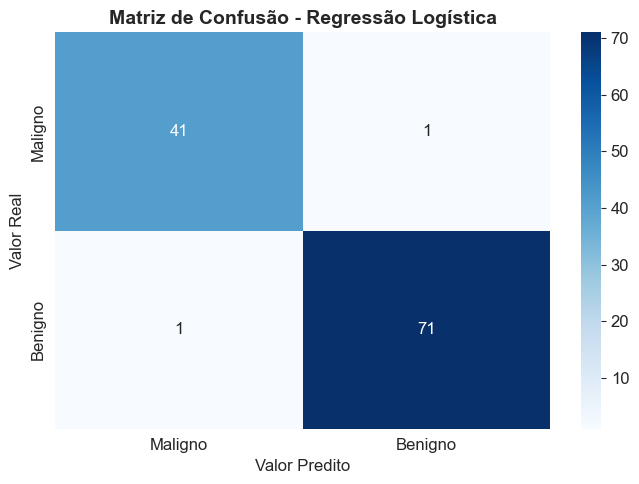

In [142]:
# Modelo 1: Regressão Logística
# Escolhemos este modelo como baseline por ser simples e rápido
modelo_lr = LogisticRegression(max_iter=10000, random_state=42)
modelo_lr.fit(X_treino_scaled, y_treino)

# Predições
y_pred_lr = modelo_lr.predict(X_teste_scaled)
y_prob_lr = modelo_lr.predict_proba(X_teste_scaled)[:, 0]

# Avaliação
print("REGRESSÃO LOGÍSTICA - Classification Report")
print("=" * 50)
exibir_classification_report(y_teste, y_pred_lr, ['Maligno', 'Benigno'])

# Matriz de confusão
plotar_matriz_confusao(y_teste, y_pred_lr, ['Maligno', 'Benigno'],
                       titulo='Matriz de Confusão - Regressão Logística',
                       salvar_em=os.path.join(DIR_RESULTADOS, 'cm_mc_regressao_logistica.png'))

### Análise dos resultados – Regressão Logística

Observando a matriz de confusão gerada acima, é possível ver quantos casos malignos e benignos foram classificados corretamente, e onde o modelo errou.

O ponto mais importante aqui não é só o total de acertos — é entender o tipo de erro. No contexto de diagnóstico de câncer, um falso negativo (tumor maligno classificado como benigno) é muito mais grave do que um falso positivo (tumor benigno classificado como maligno). O falso negativo pode atrasar um diagnóstico crítico; o falso positivo leva a mais exames, o que é ruim, mas recuperável.

Analisando o classification report, o modelo apresentou valores altos de precisão, recall e F1-score para ambas as classes. A acurácia geral também ficou em um nível alto, mas não é a métrica principal aqui — em problemas médicos, o recall da classe maligna tem muito mais peso do que acertar no geral.

De forma geral, a Regressão Logística mostrou que um modelo simples já consegue aprender padrões relevantes nesse dataset.

---

### Questionamentos sobre os resultados

- O que causou os erros que o modelo cometeu? Existe algum padrão entre os casos que foram classificados incorretamente?
- A acurácia alta poderia estar mascarando algum problema específico com uma das classes em situações menos representadas nos dados?
- Esse desempenho se manteria com dados de outro hospital, ou o modelo está ajustado demais para as particularidades desse dataset?
- Modelos mais complexos conseguiriam reduzir os erros restantes, ou o problema já está bem resolvido com essa abordagem linear?

---

Mesmo com bons resultados, é importante não concluir que o modelo está pronto para uso clínico só pelos números — a análise crítica dos erros e a validação em outros contextos são passos fundamentais antes de qualquer aplicação real.

Grafico salvo em: ..\resultados\cm_plot_regressao_logistica.png


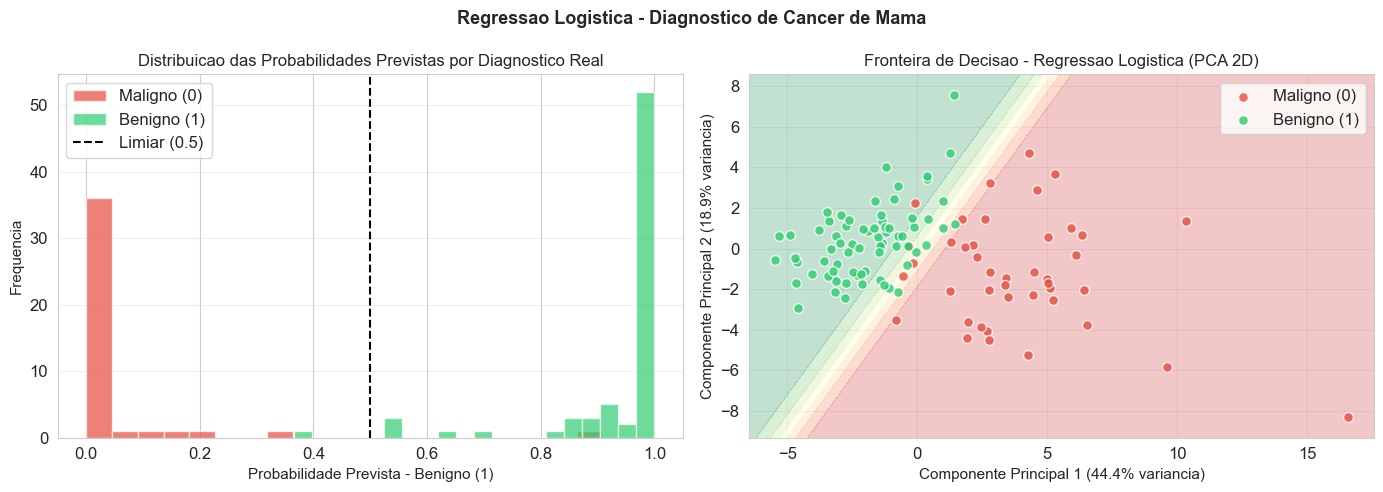

In [143]:
# Plot da Regressão Logística - Distribuição das Probabilidades e Fronteira de Decisão
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Distribuição das probabilidades previstas por diagnóstico real ---
y_prob_benigno_plot = modelo_lr.predict_proba(X_teste_scaled)[:, 1]

cores   = {0: '#e74c3c', 1: '#2ecc71'}
rotulos = {0: 'Maligno (0)', 1: 'Benigno (1)'}

ax1 = axes[0]
for classe, cor in cores.items():
    mask = y_teste == classe
    ax1.hist(y_prob_benigno_plot[mask], bins=20, alpha=0.7, color=cor,
             label=rotulos[classe], edgecolor='white')

ax1.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, label='Limiar (0.5)')
ax1.set_xlabel('Probabilidade Prevista - Benigno (1)', fontsize=11)
ax1.set_ylabel('Frequencia', fontsize=11)
titulo_p1 = 'Distribuicao das Probabilidades Previstas por Diagnostico Real'
ax1.set_title(titulo_p1, fontsize=12)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# --- Plot 2: Fronteira de decisão via PCA 2D ---
pca_lr = PCA(n_components=2, random_state=42)
X_treino_pca = pca_lr.fit_transform(X_treino_scaled)
X_teste_pca  = pca_lr.transform(X_teste_scaled)

modelo_lr_pca = LogisticRegression(max_iter=10000, random_state=42)
modelo_lr_pca.fit(X_treino_pca, y_treino)

x_min, x_max = X_teste_pca[:, 0].min() - 1, X_teste_pca[:, 0].max() + 1
y_min, y_max = X_teste_pca[:, 1].min() - 1, X_teste_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = modelo_lr_pca.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
Z = Z.reshape(xx.shape)

ax2 = axes[1]
ax2.contourf(xx, yy, Z, alpha=0.25, cmap='RdYlGn')
for classe, cor in cores.items():
    mask = y_teste.values == classe
    ax2.scatter(X_teste_pca[mask, 0], X_teste_pca[mask, 1],
                c=cor, label=rotulos[classe], alpha=0.8, edgecolor='white', s=50)

var1 = pca_lr.explained_variance_ratio_[0] * 100
var2 = pca_lr.explained_variance_ratio_[1] * 100
ax2.set_xlabel(f'Componente Principal 1 ({var1:.1f}% variancia)', fontsize=11)
ax2.set_ylabel(f'Componente Principal 2 ({var2:.1f}% variancia)', fontsize=11)
ax2.set_title('Fronteira de Decisao - Regressao Logistica (PCA 2D)', fontsize=12)
ax2.legend()
ax2.grid(alpha=0.3)

fig.suptitle('Regressao Logistica - Diagnostico de Cancer de Mama',
             fontsize=13, fontweight='bold')
plt.tight_layout()
caminho_plot_lr = os.path.join(DIR_RESULTADOS, 'cm_plot_regressao_logistica.png')
plt.savefig(caminho_plot_lr, dpi=150, bbox_inches='tight')
print(f'Grafico salvo em: {caminho_plot_lr}')
plt.show()

### Visualização da Regressão Logística

Os dois gráficos acima complementam a análise com uma perspectiva visual direta sobre como o modelo separa as classes de **diagnóstico**.
Importante destacar que essa visualização em PCA 2D é uma simplificação gráfica. O modelo principal utilizado nas métricas foi treinado no espaço original com todas as variáveis.
---

**1. Distribuição das Probabilidades Previstas**

O histograma mostra, para cada diagnóstico real (**Maligno (0)** e **Benigno (1)**), como o modelo distribuiu as probabilidades previstas para a classe **Benigno (1)**.. Um modelo bem calibrado concentra os casos Malignos próximos de 0 e os Benignos próximos de 1, formando duas distribuições bem separadas.

O limiar padrão de **0.5** divide o eixo em duas regiões de decisão. A sobreposição entre as distribuições representa a zona de incerteza — casos nessa região são os mais propensos a erros de classificação.

---

**2. Fronteira de Decisão (PCA 2D)**

Como o dataset possui muitas features, não é possível visualizar a fronteira de decisão no espaço original. Para isso, aplicamos **PCA** para reduzir os dados a 2 componentes principais e retreinamos a Regressão Logística nesse espaço reduzido.

A linha que separa as regiões coloridas é a **fronteira de decisão linear** aprendida pelo modelo. Casos na região verde são classificados como Benigno; na região vermelha, como Maligno.

> **Atenção:** A fronteira exibida é treinada no espaço PCA 2D e serve como aproximação visual. O modelo real utiliza todas as features do dataset.

### 4.2 Modelo 2: KNN (K-Nearest Neighbors)

O KNN é um dos algoritmos mais simples de entender: para classificar uma nova amostra, ele olha para os K exemplos mais próximos nos dados de treino e decide pela classe majoritária entre eles. Não há um modelo matemático sendo aprendido — a "inteligência" está toda nos dados armazenados.

Por isso o KNN é chamado de algoritmo de aprendizado preguiçoso (*lazy learning*): ele não processa nada no treino, apenas memoriza. Todo o trabalho acontece na hora de fazer uma previsão.

### Por que o valor de K precisa ser escolhido com cuidado?

K controla o tamanho da "vizinhança" consultada em cada previsão:

- K muito pequeno (por exemplo, K=1): o modelo se baseia em apenas um vizinho, ficando muito sensível a ruídos e outliers. Qualquer ponto atípico no treino pode distorcer a previsão.
- K muito grande: o modelo consulta vizinhos cada vez mais distantes, perdendo a capacidade de capturar padrões locais e ficando genérico demais.

Além disso, usamos apenas valores ímpares de K para evitar empates na votação — se metade dos vizinhos for maligna e a outra metade benigna, um K par não consegue desempatar.

  -> Gráfico salvo em: ..\resultados\cm_melhor_k.png


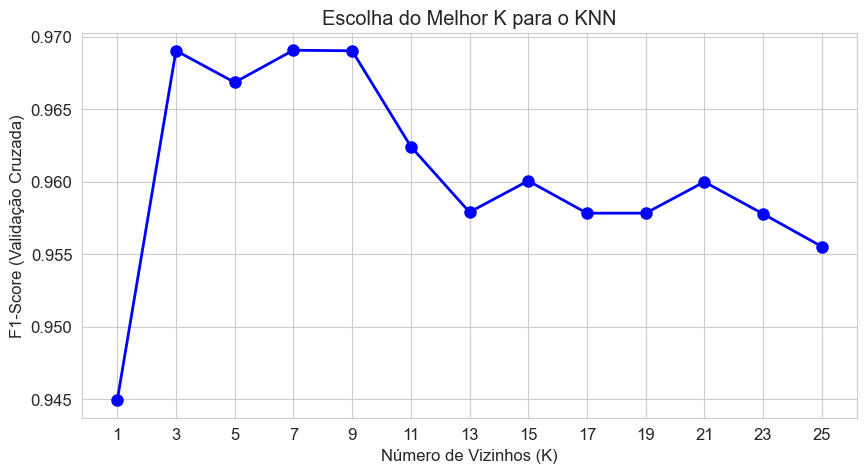

Melhor valor de K: 7 (F1-Score: 0.9691)


In [144]:
# Encontrar o melhor valor de K usando validação cruzada
# Testamos valores ímpares de 1 a 25 para evitar empates na votação
valores_k = range(1, 26, 2)
scores_k = []

for k in valores_k:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_temp, X_treino_scaled, y_treino, cv=5, scoring='f1_weighted')
    scores_k.append(scores.mean())

# Plotar resultado
plt.figure(figsize=(10, 5))
plt.plot(list(valores_k), scores_k, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de Vizinhos (K)')
plt.ylabel('F1-Score (Validação Cruzada)')
plt.title('Escolha do Melhor K para o KNN')
plt.xticks(list(valores_k))
plt.grid(True)
plt.savefig(os.path.join(DIR_RESULTADOS, 'cm_melhor_k.png'), dpi=150, bbox_inches='tight')
print(f"  -> Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'cm_melhor_k.png')}")
plt.show()

melhor_k = list(valores_k)[np.argmax(scores_k)]
print(f"Melhor valor de K: {melhor_k} (F1-Score: {max(scores_k):.4f})")

KNN (K=7) - Classification Report
              precision    recall  f1-score   support

     Maligno       1.00      0.93      0.96        42
     Benigno       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

  -> Grafico salvo em: ..\resultados\cm_mc_knn.png


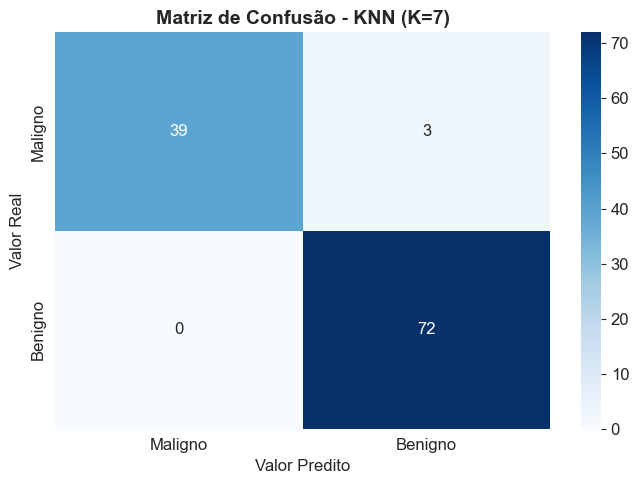

In [145]:
# Modelo 2: KNN com o melhor K encontrado
modelo_knn = KNeighborsClassifier(n_neighbors=melhor_k)
modelo_knn.fit(X_treino_scaled, y_treino)

# Predições
y_pred_knn = modelo_knn.predict(X_teste_scaled)
y_prob_knn = modelo_knn.predict_proba(X_teste_scaled)[:, 0]

# Avaliação
print(f"KNN (K={melhor_k}) - Classification Report")
print("=" * 50)
exibir_classification_report(y_teste, y_pred_knn, ['Maligno', 'Benigno'])

# Matriz de confusão
plotar_matriz_confusao(y_teste, y_pred_knn, ['Maligno', 'Benigno'],
                       titulo=f'Matriz de Confusão - KNN (K={melhor_k})',
                       salvar_em=os.path.join(DIR_RESULTADOS, 'cm_mc_knn.png'))

Grafico salvo em: ..\resultados\cm_knn_regioes_decisao.png


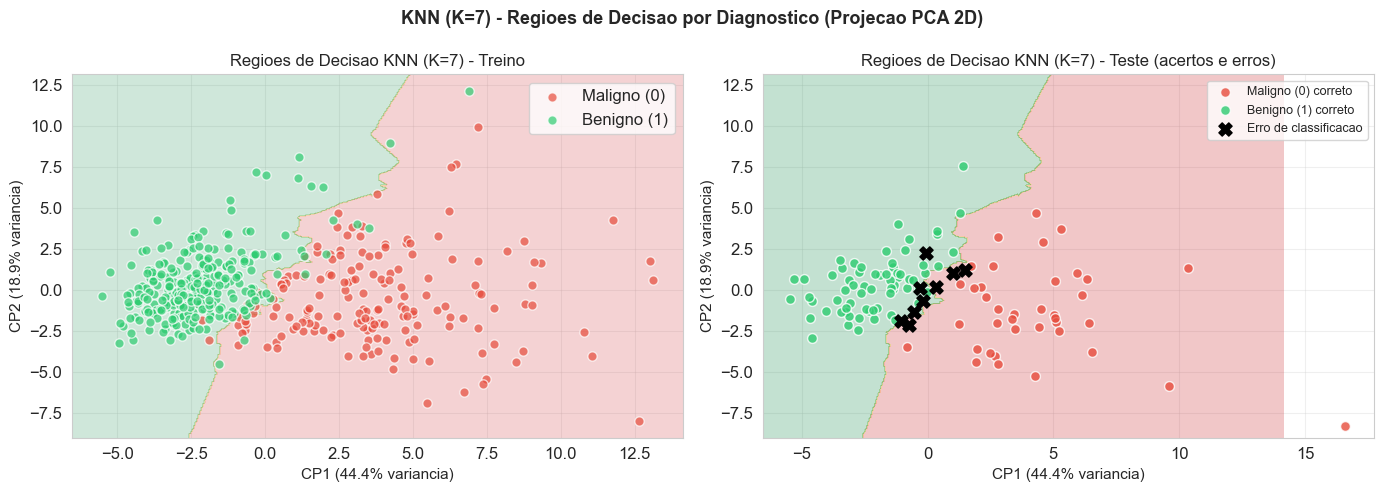

In [146]:
# Visualizacao das Regioes de Decisao do KNN - Diagnostico de Cancer de Mama
from sklearn.decomposition import PCA

cores   = {0: '#e74c3c', 1: '#2ecc71'}
rotulos = {0: 'Maligno (0)', 1: 'Benigno (1)'}

# Projecao PCA 2D - treinar KNN nesse espaco para plotar regioes
pca_knn = PCA(n_components=2, random_state=42)
X_treino_pca_knn = pca_knn.fit_transform(X_treino_scaled)
X_teste_pca_knn  = pca_knn.transform(X_teste_scaled)

modelo_knn_pca = KNeighborsClassifier(n_neighbors=melhor_k)
modelo_knn_pca.fit(X_treino_pca_knn, y_treino)

# Grade de pontos para calcular a fronteira
x_min = X_treino_pca_knn[:, 0].min() - 1
x_max = X_treino_pca_knn[:, 0].max() + 1
y_min = X_treino_pca_knn[:, 1].min() - 1
y_max = X_treino_pca_knn[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
Z = modelo_knn_pca.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

var1 = pca_knn.explained_variance_ratio_[0] * 100
var2 = pca_knn.explained_variance_ratio_[1] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Regioes de decisao com dados de TREINO ---
ax1 = axes[0]
ax1.contourf(xx, yy, Z, alpha=0.20, cmap='RdYlGn')
for classe, cor in cores.items():
    mask = y_treino.values == classe
    ax1.scatter(X_treino_pca_knn[mask, 0], X_treino_pca_knn[mask, 1],
                c=cor, label=rotulos[classe], alpha=0.7, edgecolor='white', s=45)
ax1.set_xlabel(f'CP1 ({var1:.1f}% variancia)', fontsize=11)
ax1.set_ylabel(f'CP2 ({var2:.1f}% variancia)', fontsize=11)
ax1.set_title(f'Regioes de Decisao KNN (K={melhor_k}) - Treino', fontsize=12)
ax1.legend()
ax1.grid(alpha=0.3)

# --- Plot 2: Regioes de decisao com dados de TESTE e acertos/erros marcados ---
ax2 = axes[1]
ax2.contourf(xx, yy, Z, alpha=0.25, cmap='RdYlGn')

y_pred_knn_pca = modelo_knn_pca.predict(X_teste_pca_knn)
acertos = y_teste.values == y_pred_knn_pca
erros   = ~acertos

for classe, cor in cores.items():
    mask = (y_teste.values == classe) & acertos
    ax2.scatter(X_teste_pca_knn[mask, 0], X_teste_pca_knn[mask, 1],
                c=cor, label=f'{rotulos[classe]} correto', alpha=0.8, edgecolor='white', s=50)

ax2.scatter(X_teste_pca_knn[erros, 0], X_teste_pca_knn[erros, 1],
            c='black', marker='X', s=90, label='Erro de classificacao', zorder=5)

ax2.set_xlabel(f'CP1 ({var1:.1f}% variancia)', fontsize=11)
ax2.set_ylabel(f'CP2 ({var2:.1f}% variancia)', fontsize=11)
ax2.set_title(f'Regioes de Decisao KNN (K={melhor_k}) - Teste (acertos e erros)', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

fig.suptitle(f'KNN (K={melhor_k}) - Regioes de Decisao por Diagnostico (Projecao PCA 2D)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
caminho_knn_plot = os.path.join(DIR_RESULTADOS, 'cm_knn_regioes_decisao.png')
plt.savefig(caminho_knn_plot, dpi=150, bbox_inches='tight')
print(f'Grafico salvo em: {caminho_knn_plot}')
plt.show()

### Visualização das Regiões de Decisão do KNN

Os dois gráficos acima ilustram como o algoritmo KNN organiza o espaço de decisão para classificar os diagnósticos de câncer de mama.

Como o dataset possui múltiplas variáveis, foi aplicada a técnica de **Análise de Componentes Principais (PCA)** para reduzir a dimensionalidade para duas componentes principais, permitindo a visualização gráfica.

---

### Gráfico 1 — Dados de Treino

Mostra as regiões de decisão aprendidas pelo KNN no espaço PCA 2D, com os pontos do conjunto de treino sobrepostos.

- Região verde: classificada como **Benigno (1)**
- Região vermelha: classificada como **Maligno (0)**

As fronteiras observadas são não lineares e irregulares, característica natural do KNN, pois o algoritmo define a classe com base na vizinhança local de cada ponto.

---

### Gráfico 2 — Dados de Teste

Apresenta o conjunto de teste sobre as mesmas regiões de decisão.

Os pontos marcados com **X preto** representam erros de classificação.

Observa-se que esses erros tendem a ocorrer próximos às fronteiras entre classes, regiões em que há maior sobreposição entre amostras benignas e malignas.

---

### Interpretação

O comportamento visual reforça que o KNN é eficiente quando classes semelhantes permanecem agrupadas no espaço de atributos, mas pode apresentar dificuldade em regiões de transição entre grupos.

---

> **Atenção:** Esta visualização foi construída no espaço PCA 2D apenas para interpretação gráfica. O modelo principal utilizado nas métricas oficiais foi treinado no conjunto original escalonado com todas as variáveis disponíveis.

### 4.2 Modelo 2: KNN (K-Nearest Neighbors)

O segundo modelo utilizado foi o KNN (K-Nearest Neighbors). Diferente da Regressão Logística, esse algoritmo não cria um modelo matemático explícito, mas faz previsões com base nos dados mais próximos de cada amostra.

A ideia do KNN é simples: para classificar um novo dado, o algoritmo analisa os K vizinhos mais próximos e define a classe com base na maioria deles.

---

### Escolha do melhor valor de K

Um ponto importante no KNN é definir o valor de K (número de vizinhos). Valores muito baixos podem deixar o modelo sensível a ruídos — o modelo "decora" os dados de treino mas erra em dados novos. Valores muito altos tornam o modelo genérico demais e podem fazer ele perder fronteiras importantes entre as classes.

Para não escolher no chute, testamos diferentes valores de K (de 1 a 25, apenas ímpares para evitar empates na votação por maioria) usando validação cruzada. O melhor K foi selecionado automaticamente com base no F1-Score médio, e o resultado está no gráfico gerado acima.

---

### Treinamento e avaliação do modelo

Com o melhor K definido, o modelo foi treinado com os dados de treino e avaliado no conjunto de teste.

Os resultados estão na matriz de confusão e no classification report acima. Vale observar especialmente os falsos negativos — casos malignos classificados como benignos — que são o tipo de erro mais crítico nesse contexto.

---

### Análise dos resultados

O KNN apresentou bom desempenho geral, mas ficou abaixo da Regressão Logística principalmente no recall da classe Maligno. Isso significa que ele deixou passar mais casos malignos do que a Regressão Logística.

Um ponto interessante do KNN é que ele não faz suposições sobre a distribuição dos dados — ele simplesmente "vota" com base nos vizinhos mais próximos. Isso pode ser uma vantagem em problemas onde os dados não seguem uma distribuição clara, mas também torna o modelo mais dependente da qualidade e da escala dos dados.

---

### Questionamentos sobre o uso do KNN

- O melhor K foi encontrado com os dados que temos, mas será que esse valor funcionaria bem em dados de outro hospital ou de outra época?
- O KNN não tem um "modelo" que pode ser inspecionado depois do treino — para cada nova previsão ele precisa consultar todos os dados de treino. Isso seria viável num sistema hospitalar com grandes volumes de exames?
- Como o KNN é sensível à escala, qualquer variável com valores muito maiores dominaria o cálculo de distância. O escalonamento que aplicamos antes foi fundamental — mas e se os dados chegassem em escalas diferentes no futuro?
- Os falsos negativos encontrados poderiam ser reduzidos ajustando o limiar de decisão, sem necessariamente mudar o K?

---

Esses pontos mostram que, apesar de bons resultados, o KNN também tem limitações práticas que precisam ser consideradas antes de qualquer uso real.

### 4.3 Modelo 3: Árvore de Decisão

A Árvore de Decisão aprende fazendo perguntas sobre os dados: "o raio médio é maior que X? Se sim, vai para esse lado; se não, para o outro." Esse processo se repete até chegar a uma folha com a classificação final.

A grande vantagem é a interpretabilidade — as regras geradas podem ser lidas e compreendidas por qualquer pessoa, o que é especialmente relevante em contextos médicos onde explicar o motivo de uma classificação é tão importante quanto acertar.

### Por que usar dados escalonados se a Árvore de Decisão não precisa?

Diferentemente da Regressão Logística e do KNN, a Árvore de Decisão não é sensível à escala das variáveis. As divisões que ela aprende são baseadas em limiares relativos dentro de cada feature, não em distâncias entre pontos.

Ainda assim, optamos por usar os dados escalonados para manter a comparação entre os três modelos justa e consistente — todos treinados com o mesmo conjunto de entrada. Se cada modelo recebesse dados em formatos diferentes, qualquer diferença de desempenho poderia vir do pré-processamento e não do algoritmo em si.

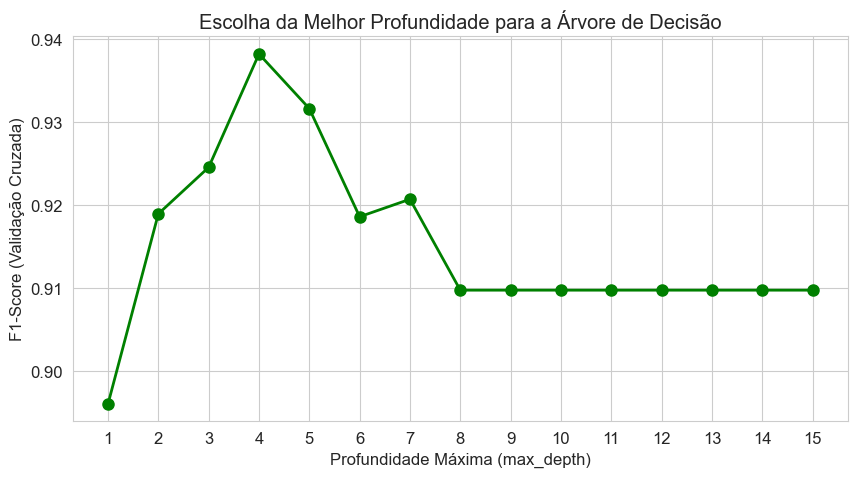

Melhor max_depth encontrado: 4 (F1=0.9382)

ÁRVORE DE DECISÃO (max_depth=4) - Classification Report
              precision    recall  f1-score   support

     Maligno       0.91      0.93      0.92        42
     Benigno       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114

  -> Grafico salvo em: ..\resultados\cm_mc_arvore_decisao.png


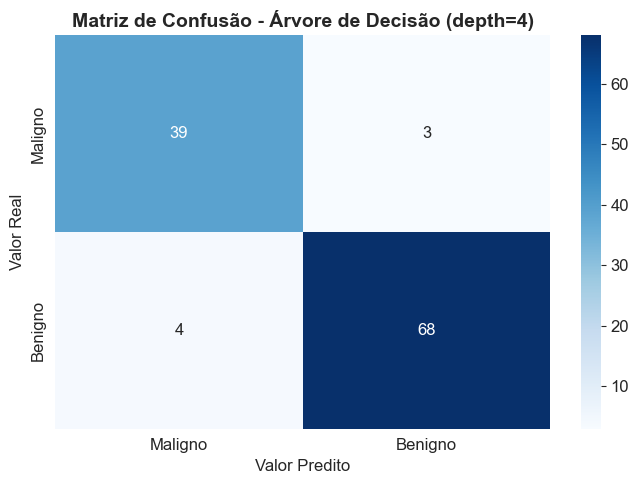

In [147]:
  # Buscar a melhor profundidade usando validação cruzada
# (mesmo padrão usado para o K no KNN)
profundidades = range(1, 16)
scores_depth = []

for depth in profundidades:
    arvore_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(arvore_temp, X_treino_scaled, y_treino, cv=5, scoring='f1_weighted')
    scores_depth.append(scores.mean())

# Plotar resultado
plt.figure(figsize=(10, 5))
plt.plot(list(profundidades), scores_depth, 'go-', linewidth=2, markersize=8)
plt.xlabel('Profundidade Máxima (max_depth)')
plt.ylabel('F1-Score (Validação Cruzada)')
plt.title('Escolha da Melhor Profundidade para a Árvore de Decisão')
plt.xticks(list(profundidades))
plt.grid(True)
plt.savefig(os.path.join(DIR_RESULTADOS, 'cm_melhor_depth.png'), dpi=150, bbox_inches='tight')
plt.show()

melhor_depth = list(profundidades)[scores_depth.index(max(scores_depth))]
print(f"Melhor max_depth encontrado: {melhor_depth} (F1={max(scores_depth):.4f})")

# Modelo 3: Árvore de Decisão com a melhor profundidade encontrada
modelo_arvore = DecisionTreeClassifier(max_depth=melhor_depth, random_state=42)
modelo_arvore.fit(X_treino_scaled, y_treino)

# Predições
y_pred_arvore = modelo_arvore.predict(X_teste_scaled)
y_prob_arvore = modelo_arvore.predict_proba(X_teste_scaled)[:, 0]

# Avaliação
print(f"\nÁRVORE DE DECISÃO (max_depth={melhor_depth}) - Classification Report")
print("=" * 50)
exibir_classification_report(y_teste, y_pred_arvore, ['Maligno', 'Benigno'])

# Matriz de confusão
plotar_matriz_confusao(y_teste, y_pred_arvore, ['Maligno', 'Benigno'],
                       titulo=f'Matriz de Confusão - Árvore de Decisão (depth={melhor_depth})',
                       salvar_em=os.path.join(DIR_RESULTADOS, 'cm_mc_arvore_decisao.png'))


Grafico salvo em: ..\resultados\cm_arvore_decisao_estrutura.png


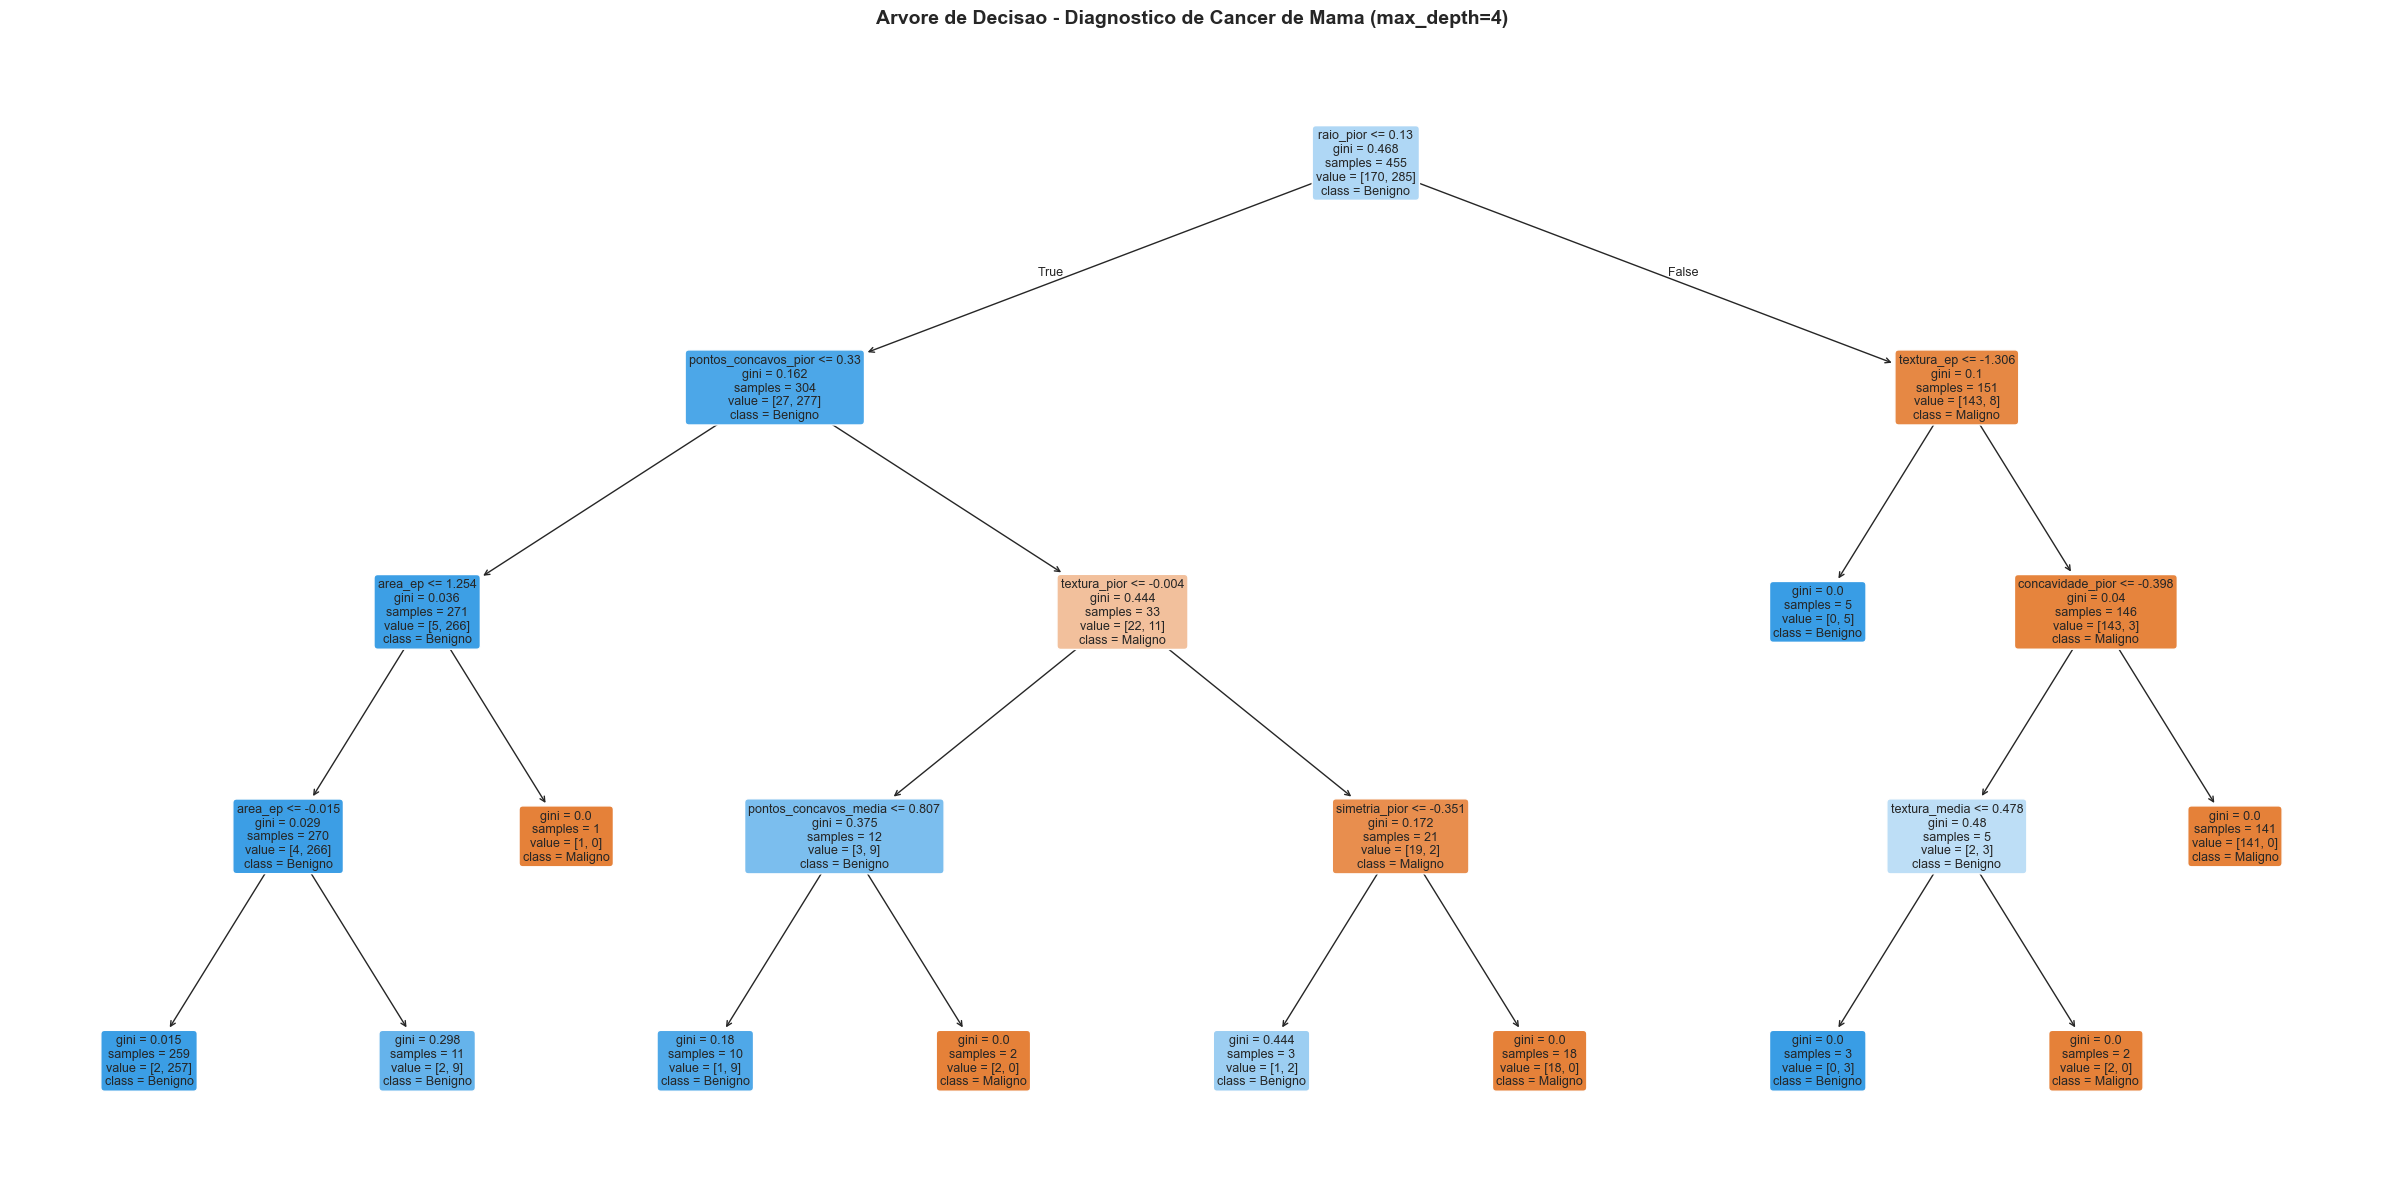

Nos totais na arvore: 21
Folhas (nos terminais): 11
Profundidade maxima usada: 4


In [148]:
# Visualização da Árvore de Decisão com a variável diagnóstico
from sklearn.tree import plot_tree

feature_names = X.columns.tolist()

fig, ax = plt.subplots(figsize=(24, 12))

plot_tree(
    modelo_arvore,
    feature_names=feature_names,
    class_names=['Maligno', 'Benigno'],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    ax=ax,
    fontsize=9
)

ax.set_title(
    f'Arvore de Decisao - Diagnostico de Cancer de Mama (max_depth={melhor_depth})',
    fontsize=14,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
caminho_arvore_plot = os.path.join(DIR_RESULTADOS, 'cm_arvore_decisao_estrutura.png')
plt.savefig(caminho_arvore_plot, dpi=150, bbox_inches='tight')
print(f'Grafico salvo em: {caminho_arvore_plot}')
plt.show()

# Resumo das folhas
n_nos = modelo_arvore.tree_.node_count
n_folhas = modelo_arvore.tree_.n_node_samples[modelo_arvore.tree_.children_left == -1].shape[0]
print(f'Nos totais na arvore: {n_nos}')
print(f'Folhas (nos terminais): {n_folhas}')
print(f'Profundidade maxima usada: {modelo_arvore.get_depth()}')

### Visualização da Árvore de Decisão

O gráfico acima exibe a estrutura final da Árvore de Decisão treinada para classificar os diagnósticos de câncer de mama, limitada à profundidade ótima definida no processo de ajuste de hiperparâmetros (`max_depth = {melhor_depth}`).

A restrição de profundidade foi aplicada para reduzir o risco de overfitting e melhorar a capacidade de generalização do modelo.

---

### Como ler cada nó

Cada caixa da árvore apresenta as seguintes informações:

- **Feature e limiar** (`feature <= valor`): regra utilizada para dividir os dados;
- **Gini**: medida de impureza do nó. Quanto menor o valor, mais homogêneo é o grupo;
- **Samples**: quantidade de amostras presentes no nó;
- **Value**: distribuição das classes no formato `[Maligno, Benigno]`;
- **Class**: classe prevista naquele nó.

---

### Interpretação das cores

Os nós são coloridos conforme a classe predominante:

- **Laranja:** predominância de casos Malignos (0);
- **Azul:** predominância de casos Benignos (1).

Quanto mais intensa a cor, maior a pureza do nó.

---

### Como seguir a árvore

A classificação inicia no nó raiz (topo da árvore). Em cada etapa, uma regra é avaliada:

- Se a condição for verdadeira, segue para o ramo esquerdo;
- Se for falsa, segue para o ramo direito.

O processo continua até uma folha terminal, onde é realizada a classificação final da amostra.

---

### Análise crítica

A principal vantagem da Árvore de Decisão é sua elevada interpretabilidade, pois permite visualizar claramente quais variáveis influenciaram cada decisão do modelo.

Isso é especialmente relevante em aplicações médicas, onde transparência e justificativa da decisão são fatores importantes.

### 4.3 Modelo 3: Árvore de Decisão

O terceiro modelo utilizado foi a Árvore de Decisão. Esse tipo de algoritmo funciona criando regras de decisão no formato "se-então", dividindo os dados com base nas características mais relevantes até chegar a uma classificação final.

Uma das principais vantagens desse modelo é a interpretabilidade, já que é possível entender quais decisões estão sendo tomadas ao longo do processo. Além disso, diferentemente de modelos como KNN e Regressão Logística, a Árvore de Decisão não é sensível à escala dos dados. Mesmo assim, foi mantido o uso dos dados escalonados para garantir consistência na comparação entre os modelos.

---

### Escolha do parâmetro `max_depth`

Um dos parâmetros mais importantes da Árvore de Decisão é o `max_depth`, que define até onde a árvore pode crescer. Sem esse limite, a árvore cresce até separar perfeitamente os dados de treino — o que parece bom, mas na prática significa que o modelo "decorou" os dados e vai errar muito em dados novos. Isso se chama overfitting.

Por outro lado, uma árvore muito rasa pode simplificar demais o problema e não aprender o suficiente — o que se chama underfitting.

Para não escolher esse valor no chute, aplicamos a mesma estratégia usada no KNN: testamos várias profundidades usando validação cruzada e selecionamos automaticamente o valor com melhor desempenho médio. O resultado dessa busca está na saída da célula acima.

---

### Treinamento e avaliação do modelo

Após definir a melhor profundidade pela busca, o modelo foi treinado com os dados de treino e avaliado no conjunto de teste.

Os resultados estão na matriz de confusão e no classification report gerados acima. Vale prestar atenção nos falsos negativos — casos malignos que o modelo classificou como benignos — pois esse é o tipo de erro mais crítico no contexto de diagnóstico de câncer.

---

### Análise dos resultados

Comparando com os outros dois modelos, a Árvore de Decisão tende a apresentar desempenho inferior nesse tipo de problema. Isso acontece porque árvores individuais são naturalmente mais instáveis: pequenas variações nos dados de treino podem gerar estruturas bem diferentes.

A principal vantagem da Árvore de Decisão está na interpretabilidade. As regras que ela gera podem ser lidas por qualquer pessoa, o que pode ser útil em contextos médicos onde é importante explicar o motivo da classificação.

---

### Questionamentos sobre o uso da Árvore de Decisão

- A busca por validação cruzada encontra o melhor valor de `max_depth` dentro dos dados que temos, mas será que esse valor generalizaria bem em dados de outro hospital ou de outra época?
- A Árvore de Decisão é instável por natureza. Faria sentido usar uma técnica como Random Forest, que combina várias árvores para ter um resultado mais estável?
- Mesmo sendo mais interpretável, vale a pena usar um modelo com desempenho inferior num sistema de apoio ao diagnóstico?
- Os falsos negativos encontrados poderiam ser reduzidos ajustando o limiar de decisão do modelo?

---

Esses questionamentos mostram que, apesar de ser simples e interpretável, a Árvore de Decisão pode não ser a melhor escolha isoladamente para esse problema.

---
## 5. Avaliação Comparativa dos Modelos

Agora vamos comparar os três modelos lado a lado para entender qual teve o melhor desempenho. 

### 5.1 Tabela Comparativa de Métricas

Depois de treinar e avaliar os três modelos separadamente, foi feita uma comparação geral entre eles. Essa etapa é importante porque permite observar lado a lado o desempenho da Regressão Logística, do KNN e da Árvore de Decisão no mesmo conjunto de teste.

Foram comparadas métricas gerais, como acurácia, precisão ponderada, recall ponderado e F1-Score ponderado. Essas métricas ajudam a ter uma visão geral do comportamento de cada modelo, considerando o desempenho nas duas classes: maligno e benigno.

No entanto, como o problema está relacionado ao diagnóstico de câncer de mama, apenas olhar para as métricas gerais pode não ser suficiente. Nesse contexto, um dos erros mais críticos é o falso negativo, que ocorre quando um tumor maligno é classificado como benigno.

Por esse motivo, além das métricas gerais, também foi incluído o recall específico da classe Maligno e a quantidade de falsos negativos para essa classe. Essa análise é importante porque o recall maligno mostra, entre os casos realmente malignos, quantos o modelo conseguiu identificar corretamente.

Dessa forma, a comparação fica mais alinhada ao objetivo do projeto, que é avaliar qual modelo pode apoiar melhor uma triagem inicial, reduzindo principalmente o risco de deixar passar casos malignos.


In [149]:
# Calcular métricas para cada modelo
metricas_lr = avaliar_modelo_cancer_mama(
    y_teste, 
    y_pred_lr, 
    'Regressão Logística'
)

metricas_knn = avaliar_modelo_cancer_mama(
    y_teste, 
    y_pred_knn, 
    f'KNN (K={melhor_k})'
)

metricas_arvore = avaliar_modelo_cancer_mama(
    y_teste, 
    y_pred_arvore, 
    'Árvore de Decisão'
)

# Tabela comparativa
lista_metricas = [metricas_lr, metricas_knn, metricas_arvore]
df_comparacao, df_formatado = comparar_modelos(lista_metricas)

print("COMPARAÇÃO DOS MODELOS")
print("=" * 60)
print(df_comparacao.to_string())
print()

# Identificar o melhor modelo pelo recall da classe Maligno
melhor_recall = df_comparacao['Recall Maligno'].idxmax()

print(f"-> Melhor modelo considerando Recall da classe Maligno: {melhor_recall}")
print(f"  Recall Maligno = {df_comparacao.loc[melhor_recall, 'Recall Maligno']:.4f}")
print(f"  Falsos Negativos Maligno = {df_comparacao.loc[melhor_recall, 'Falsos Negativos Maligno']:.0f}")

# Exibir tabela formatada
df_formatado

COMPARAÇÃO DOS MODELOS
                     Acurácia  Precisão Weighted  Recall Weighted  F1-Score Weighted  Recall Maligno  F1-Score Maligno  Falsos Negativos Maligno
Modelo                                                                                                                                          
Regressão Logística  0.982456           0.982456         0.982456           0.982456        0.976190          0.976190                         1
KNN (K=7)            0.973684           0.974737         0.973684           0.973465        0.928571          0.962963                         3
Árvore de Decisão    0.938596           0.939042         0.938596           0.938743        0.928571          0.917647                         3

-> Melhor modelo considerando Recall da classe Maligno: Regressão Logística
  Recall Maligno = 0.9762
  Falsos Negativos Maligno = 1


,Acurácia,Precisão Weighted,Recall Weighted,F1-Score Weighted,Recall Maligno,F1-Score Maligno,Falsos Negativos Maligno
Modelo,,,,,,,
Regressão Logística,0.9825,0.9825,0.9825,0.9825,0.9762,0.9762,1
KNN (K=7),0.9737,0.9747,0.9737,0.9735,0.9286,0.9630,3
Árvore de Decisão,0.9386,0.9390,0.9386,0.9387,0.9286,0.9176,3


### Análise da comparação dos modelos

Observando a tabela gerada acima, a Regressão Logística apresentou o melhor desempenho geral entre os três modelos, com as maiores métricas de acurácia, precisão, recall e F1-score ponderados.

Além das métricas gerais, o ponto mais relevante para esse problema é o recall da classe Maligno e a quantidade de falsos negativos — e a Regressão Logística também se saiu melhor nesse critério, deixando passar menos casos malignos do que os outros dois modelos.

O KNN ficou em segundo lugar nas métricas gerais, mas apresentou mais falsos negativos do que a Regressão Logística, o que pesa contra ele no contexto de triagem médica.

A Árvore de Decisão ficou com o menor desempenho geral, tanto nas métricas globais quanto no recall maligno. Sua vantagem é a interpretabilidade, mas nesse experimento isso não compensou a diferença de desempenho.

Com base nesses resultados, a Regressão Logística foi o modelo mais adequado para esse problema.

---

### Questionamentos sobre a comparação dos modelos

- Esse resultado seria mantido com dados de outro hospital ou de outra época? O dataset aqui é pequeno e específico — é difícil afirmar que o modelo vai generalizar bem.
- A escolha pelo recall maligno como critério principal faz sentido clinicamente, mas um modelo que maximize muito o recall pode aumentar os falsos positivos. Onde está o equilíbrio aceitável?
- A Regressão Logística foi melhor porque o problema é linearmente separável, ou porque o dataset é pequeno demais para modelos mais complexos mostrarem vantagem?
- A diferença de desempenho entre os modelos é grande o suficiente para descartar o KNN e a Árvore de Decisão, ou eles ainda poderiam ser úteis em conjunto com a Regressão Logística?

---

Nenhum dos modelos deve substituir o diagnóstico médico — o uso mais adequado é como apoio à triagem, ajudando a priorizar casos que merecem atenção mais rápida.

### 5.2 Validação Cruzada

Para complementar a avaliação feita no conjunto de teste, foi aplicada a validação cruzada com 5 folds. A ideia dessa etapa é verificar se o desempenho dos modelos se mantém estável quando os dados são divididos de formas diferentes.

Na avaliação anterior, os modelos foram comparados usando uma separação fixa entre treino e teste. Esse processo é importante, mas pode depender da forma como os dados foram divididos. Com a validação cruzada, o modelo é treinado e avaliado várias vezes, utilizando diferentes partes da base em cada rodada.

Neste projeto, foi utilizada a validação cruzada estratificada, por meio do `StratifiedKFold`. Essa escolha ajuda a manter a proporção entre casos malignos e benignos em cada divisão, o que é importante em problemas de classificação médica.

Também foi utilizado um `Pipeline`, combinando o `StandardScaler` com cada modelo. Isso garante que o escalonamento seja aplicado corretamente dentro de cada fold, evitando vazamento de dados durante a validação.

Como o foco principal do problema é reduzir falsos negativos em casos malignos, a métrica utilizada nesta etapa foi o recall da classe Maligno. Dessa forma, a validação cruzada avalia a capacidade dos modelos de identificar corretamente os casos realmente malignos em diferentes divisões da base.


VALIDAÇÃO CRUZADA (5-Fold)
Regressão Logística      : Recall Maligno = 0.9647 (+/- 0.0288)
KNN (K=7)                : Recall Maligno = 0.9235 (+/- 0.0399)
Árvore de Decisão        : Recall Maligno = 0.9118 (+/- 0.0416)
  -> Gráfico salvo em: ..\resultados\cm_validacao_cruzada.png


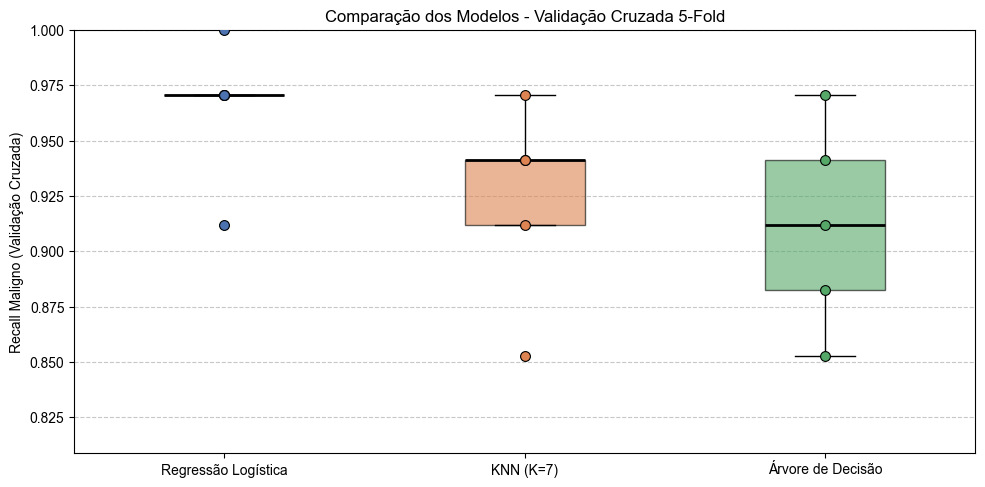

In [150]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer

# Validação cruzada com 5 folds estratificados
# O objetivo aqui é avaliar a estabilidade dos modelos considerando o recall da classe Maligno
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Scorer específico para a classe Maligno
# Considerando que: 0 = Maligno e 1 = Benigno
recall_maligno_scorer = make_scorer(
    recall_score,
    pos_label=0
)

modelos_cv = {
    'Regressão Logística': LogisticRegression(max_iter=10000, random_state=42),
    f'KNN (K={melhor_k})': KNeighborsClassifier(n_neighbors=melhor_k),
    'Árvore de Decisão': DecisionTreeClassifier(max_depth=melhor_depth, random_state=42)
}
print()
print("VALIDAÇÃO CRUZADA (5-Fold)")
print("=" * 60)

resultados_cv = {}

for nome, modelo in modelos_cv.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('modelo', modelo)
    ])

    scores = cross_val_score(
        pipeline,
        X_treino,
        y_treino,
        cv=cv,
        scoring=recall_maligno_scorer
    )

    resultados_cv[nome] = scores

    print(f"{nome:25}: Recall Maligno = {scores.mean():.4f} (+/- {scores.std():.4f})")

# Visualizar em boxplot
cores = ['#4C72B0', '#DD8452', '#55A868']

with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    bp = ax.boxplot(
        resultados_cv.values(),
        labels=resultados_cv.keys(),
        patch_artist=True,
        widths=0.4,
        medianprops=dict(color='black', linewidth=2)
    )

    for patch, cor in zip(bp['boxes'], cores):
        patch.set_facecolor(cor)
        patch.set_alpha(0.6)

    # Sobrepõe os 5 pontos individuais de cada fold
    for i, (nome, scores) in enumerate(resultados_cv.items(), start=1):
        ax.scatter(
            [i] * len(scores),
            scores,
            color=cores[i - 1],
            edgecolors='black',
            linewidths=0.8,
            zorder=5,
            s=50
        )

    y_min = min(s.min() for s in resultados_cv.values())
    y_max = max(s.max() for s in resultados_cv.values())
    margem = (y_max - y_min) * 0.3 if y_max > y_min else 0.02
    ax.set_ylim(max(0, y_min - margem), min(1.0, y_max + margem))

    ax.set_ylabel('Recall Maligno (Validação Cruzada)')
    ax.set_title('Comparação dos Modelos - Validação Cruzada 5-Fold')
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

    plt.tight_layout()

    fig.savefig(
        os.path.join(DIR_RESULTADOS, 'cm_validacao_cruzada.png'),
        dpi=150,
        bbox_inches='tight',
        facecolor='white'
    )

print(f"  -> Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'cm_validacao_cruzada.png')}")

plt.show()

### Análise da validação cruzada

A Regressão Logística apresentou o melhor desempenho médio de recall da classe Maligno entre os três modelos. Isso indica que, nas diferentes divisões dos dados de treino, ela foi a mais consistente na identificação dos casos malignos.

O KNN ficou em segundo lugar, com recall maligno um pouco menor e variação maior entre os folds, como é possível ver no boxplot.

A Árvore de Decisão apresentou o menor desempenho médio, e pelo gráfico é possível perceber também uma maior instabilidade entre os folds — o que faz sentido, já que árvores de decisão individuais são naturalmente mais sensíveis à composição dos dados de treino.

O boxplot é importante aqui porque mostra não só a média de cada modelo, mas também o quanto os resultados variam entre as divisões. Um modelo com média alta mas variação grande pode ser menos confiável do que parece.

Um ponto que vale destacar: os valores de recall obtidos na validação cruzada tendem a ser menores do que os do teste fixo. Isso é esperado, porque a validação cruzada é mais exigente — o modelo é testado várias vezes em condições diferentes, o que gera uma estimativa mais realista do desempenho.

---

### Questionamentos sobre a validação cruzada

- 5 folds são suficientes para um dataset de 569 amostras? Com mais folds, a estimativa seria mais estável ou só mais lenta?
- A variação que aparece no boxplot da Árvore de Decisão é algo que se repetiria em produção, ou é um artefato do tamanho pequeno do dataset?
- O recall da classe Maligno é a métrica mais importante aqui, mas um modelo que maximiza muito o recall pode aumentar os falsos positivos. Faz sentido olhar só para essa métrica na validação?
- Os resultados seriam diferentes se testássemos esses modelos em dados de outro hospital ou de outra população?

---

De forma geral, a validação cruzada confirmou o que já havia aparecido na comparação anterior: a Regressão Logística foi o modelo mais consistente para esse problema. Mas os resultados precisam ser interpretados com cuidado — bom desempenho nos dados que temos não garante o mesmo em dados que ainda não vimos.

### 5.3 Curvas ROC

Além das métricas tradicionais, também utilizamos a curva ROC (Receiver Operating Characteristic) para comparar os modelos de forma mais visual.

A curva ROC mostra a relação entre a taxa de verdadeiros positivos (sensibilidade) e a taxa de falsos positivos em diferentes limiares de decisão. Quanto mais próxima a curva estiver do canto superior esquerdo do gráfico, melhor o modelo — porque isso significa alta taxa de acertos e baixa taxa de falsos positivos ao mesmo tempo.

A métrica AUC (Area Under the Curve) resume esse desempenho em um único número, de 0 a 1. Quanto mais perto de 1, melhor o modelo separa as duas classes.

---

### Análise dos resultados

Observando o gráfico gerado acima, a Regressão Logística apresentou a curva mais próxima do canto superior esquerdo e o maior valor de AUC entre os três modelos — o que confirma o que já havíamos visto nas métricas anteriores.

O KNN ficou em segundo lugar, com AUC bem próximo da Regressão Logística, mostrando que ele também consegue separar bem as classes mesmo usando uma abordagem completamente diferente.

A Árvore de Decisão ficou com o menor AUC dos três. Ela ainda apresentou um resultado satisfatório, mas o poder de discriminação foi inferior.

---

### Questionamentos sobre as Curvas ROC

- A AUC é uma boa métrica para comparar modelos de forma geral, mas ela não mostra onde estão os erros. Um modelo com AUC alta pode ainda ter muitos falsos negativos em um limiar específico — o que seria crítico aqui. Faz sentido usar a AUC como critério principal de escolha?
- A curva ROC assume que podemos ajustar livremente o limiar de decisão. Na prática, qual limiar usaríamos num sistema de triagem? E quem definiria isso?
- Será que esses resultados se manteriam se testássemos os modelos em dados de outro hospital, com equipamentos diferentes e populações diferentes?
- A curva Precision-Recall poderia ser mais informativa do que a ROC em problemas com classes desbalanceadas. Valeria a pena plotá-la também?

---

A curva ROC é uma ferramenta útil para ter uma visão do desempenho além de um único ponto de corte, mas precisa ser analisada junto com as outras métricas e sempre levando em conta o contexto do problema.

  -> Grafico salvo em: ..\resultados\cm_curvas_roc.png


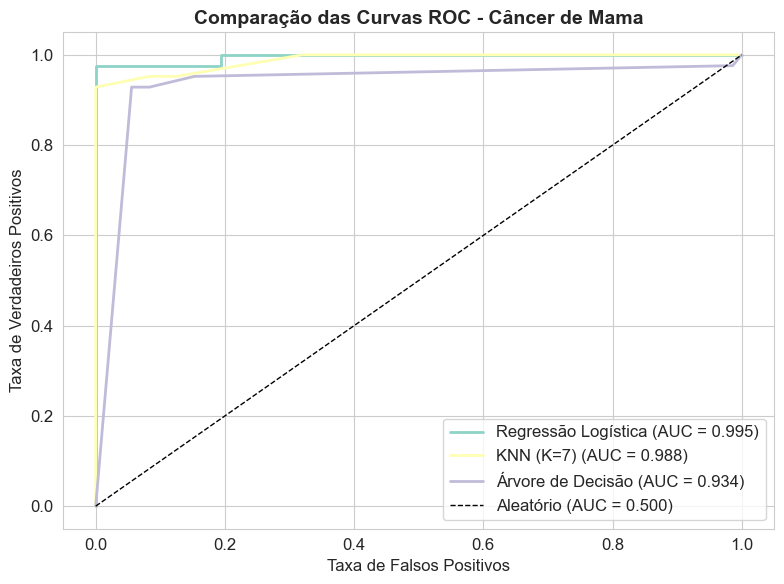

In [151]:
# Plotar curvas ROC comparativas
resultados_roc = {
    'Regressão Logística': y_prob_lr,
    f'KNN (K={melhor_k})': y_prob_knn,
    'Árvore de Decisão': y_prob_arvore
}

plotar_curvas_roc_comparativas(
    y_teste, resultados_roc,
    titulo='Comparação das Curvas ROC - Câncer de Mama',
    salvar_em=os.path.join(DIR_RESULTADOS, 'cm_curvas_roc.png'),
    pos_label=0
)

### 6. Interpretação dos Resultados

Além de avaliar o desempenho pelos números, é importante entender como o modelo chega às previsões. Em aplicações médicas isso é essencial — não basta acertar, é preciso conseguir explicar o motivo.

---

### 6.1 Feature Importance (Árvore de Decisão)

A Feature Importance mede o quanto cada variável contribuiu para as divisões feitas pela árvore ao longo do treinamento. Quanto mais vezes uma feature foi usada para separar os dados — e quanto melhor ela separou — maior a sua importância.

O gráfico e a listagem gerados acima mostram as 15 variáveis que mais influenciaram as decisões do modelo.

---

### Análise dos resultados

Observando o gráfico, é possível notar que poucas features concentram a maior parte da importância — o modelo baseia suas decisões principalmente em um grupo pequeno de variáveis, enquanto as demais têm contribuição marginal.

Um padrão interessante é que as variáveis do grupo `_pior` (que representam o pior valor medido em cada característica) tendem a aparecer entre as mais relevantes. Isso faz sentido biologicamente: em tumores malignos, os valores extremos de tamanho, irregularidade e formato costumam ser mais informativos do que a média, justamente porque o crescimento é mais descontrolado.

Esse resultado é coerente com o que se esperaria clinicamente — características ligadas ao tamanho e à irregularidade das células tendem a ser as mais diagnósticas.

---

### Interpretação prática

Saber quais features o modelo usa para decidir é útil por dois motivos: primeiro, permite validar se as decisões fazem sentido médico; segundo, pode orientar profissionais de saúde sobre quais aspectos do exame merecem mais atenção na triagem.

---

### Questionamentos sobre Feature Importance

- Uma feature muito dominante pode fazer o modelo depender excessivamente dela. O que aconteceria se ela apresentasse valores atípicos em novos dados?
- Features muito correlacionadas entre si tendem a dividir a importância — algumas podem parecer irrelevantes individualmente mas serem importantes em conjunto. Como avaliar isso?
- A importância calculada aqui é específica da Árvore de Decisão. Outros modelos, como a Regressão Logística, dariam o mesmo peso a essas variáveis?
- As features com baixa importância realmente não contribuem, ou simplesmente não foram necessárias para a profundidade que a árvore atingiu?

  -> Gráfico salvo em: ..\resultados\cm_feature_importance.png


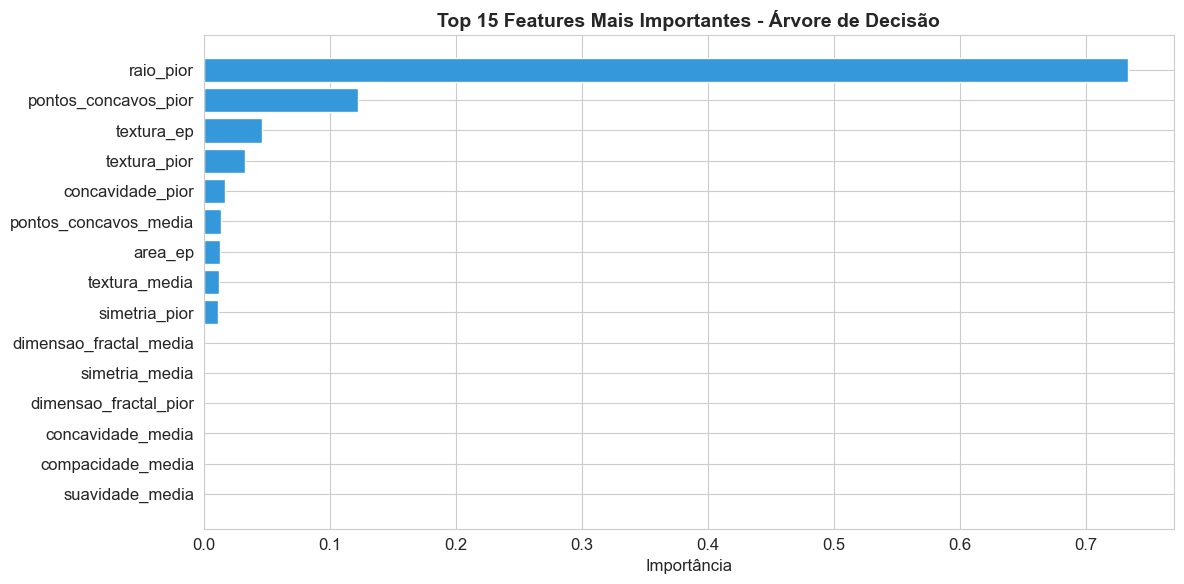

Top 10 Features mais importantes:
  1. raio_pior                      - Importância: 0.7335
  2. pontos_concavos_pior           - Importância: 0.1220
  3. textura_ep                     - Importância: 0.0458
  4. textura_pior                   - Importância: 0.0323
  5. concavidade_pior               - Importância: 0.0172
  6. pontos_concavos_media          - Importância: 0.0133
  7. area_ep                        - Importância: 0.0127
  8. textura_media                  - Importância: 0.0118
  9. simetria_pior                  - Importância: 0.0113
  10. dimensao_fractal_media         - Importância: 0.0000


In [152]:
# Feature Importance da Árvore de Decisão
feature_names = X.columns.tolist()
importancias = modelo_arvore.feature_importances_
indices = np.argsort(importancias)[::-1]

# Plotar as 15 features mais importantes
top_n = 15
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(top_n), importancias[indices[:top_n]][::-1], color='#3498db')
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names[i] for i in indices[:top_n]][::-1])
ax.set_xlabel('Importância')
ax.set_title('Top 15 Features Mais Importantes - Árvore de Decisão', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(DIR_RESULTADOS, 'cm_feature_importance.png'), dpi=150, bbox_inches='tight')
print(f"  -> Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'cm_feature_importance.png')}")
plt.show()

# Exibir valores
print("Top 10 Features mais importantes:")
for i in range(10):
    print(f"  {i+1}. {feature_names[indices[i]]:30s} - Importância: {importancias[indices[i]]:.4f}")

## 6.2 SHAP Values

A Feature Importance mostra quais variáveis foram importantes em média para o modelo inteiro. O SHAP vai um passo além: ele mostra **como cada variável influenciou cada previsão individualmente**.

Isso significa que, para uma amostra específica, é possível ver quais features empurraram a classificação para maligno e quais empurraram para benigno — e em quanto. No contexto médico, esse nível de detalhe é muito valioso para explicar uma decisão ao profissional de saúde.

---

### O que estamos analisando

Aplicamos o SHAP ao modelo de Árvore de Decisão usando o conjunto de teste. Dois gráficos foram gerados:

- **Summary plot (beeswarm)**: mostra a distribuição dos valores SHAP de cada feature para todas as amostras do teste — dá para ver tanto a importância média quanto como os valores altos e baixos de cada feature afetam a previsão.
- **Bar plot**: mostra a importância média absoluta de cada feature, similar à Feature Importance mas calculada via SHAP.

---

### Análise dos resultados

Observando os gráficos gerados acima, as features com maiores valores SHAP são as que mais influenciam as previsões — coerente com o que já vimos na Feature Importance.

Um padrão que costuma aparecer nesse dataset: valores altos nas features de tamanho e irregularidade tendem a aumentar a probabilidade de classificação como maligno, enquanto valores baixos contribuem para a classificação como benigno. Isso é esperado biologicamente — tumores malignos crescem de forma menos controlada e apresentam células mais irregulares.

---

### Por que SHAP além de Feature Importance?

A Feature Importance diz "essa variável foi importante para o modelo". O SHAP diz "para esse paciente específico, essa variável aumentou ou reduziu a probabilidade de ser maligno, e em quanto". Num sistema de apoio ao diagnóstico, essa diferença é enorme — o médico não quer saber só que determinada feature importa em geral, quer saber se o valor dela *nesse* paciente é o que está puxando o modelo para malignidade.

---

### Questionamentos sobre SHAP

- As explicações geradas pelo SHAP são específicas para o modelo que treinamos. Se o modelo mudar, as explicações mudam também — como garantir que as explicações continuem coerentes com a realidade clínica ao longo do tempo?
- Variáveis muito correlacionadas podem ter seus efeitos SHAP distribuídos de forma confusa entre elas. Isso poderia enganar um profissional que use o SHAP para tomar decisões?
- O SHAP foi aplicado à Árvore de Decisão. Seria interessante aplicá-lo também à Regressão Logística — o modelo campeão — para ver se as explicações são consistentes entre os dois?

SHAP Summary Plot - Árvore de Decisão
-> Gráfico salvo em: ..\resultados\cm_shap_summary.png


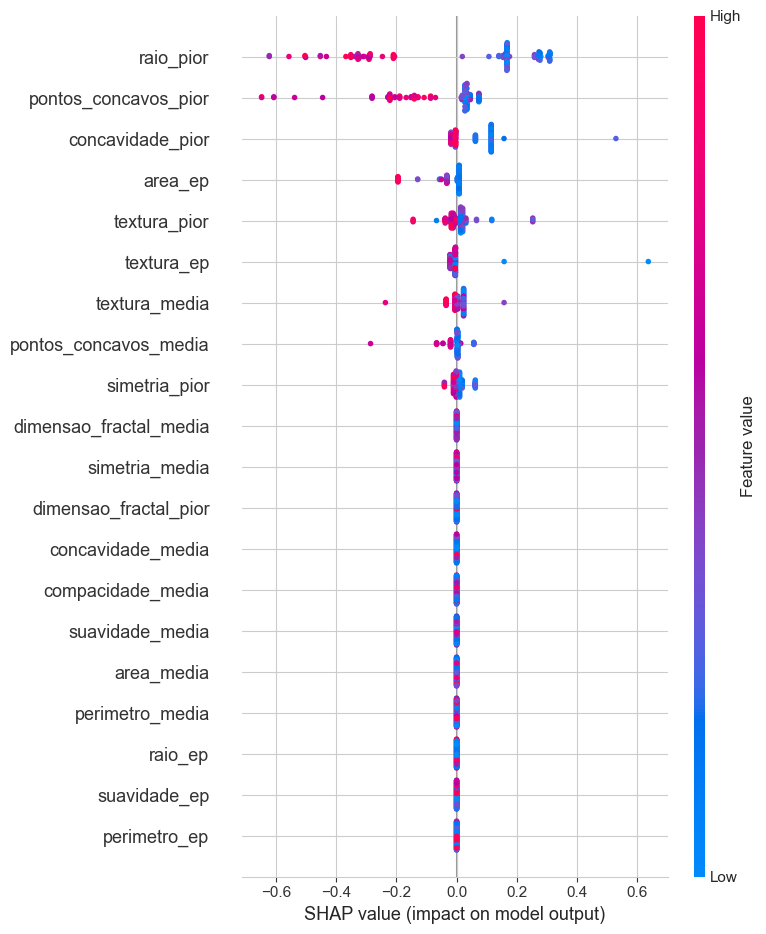

SHAP Bar Plot - Importância Média
-> Gráfico salvo em: ..\resultados\cm_shap_bar.png


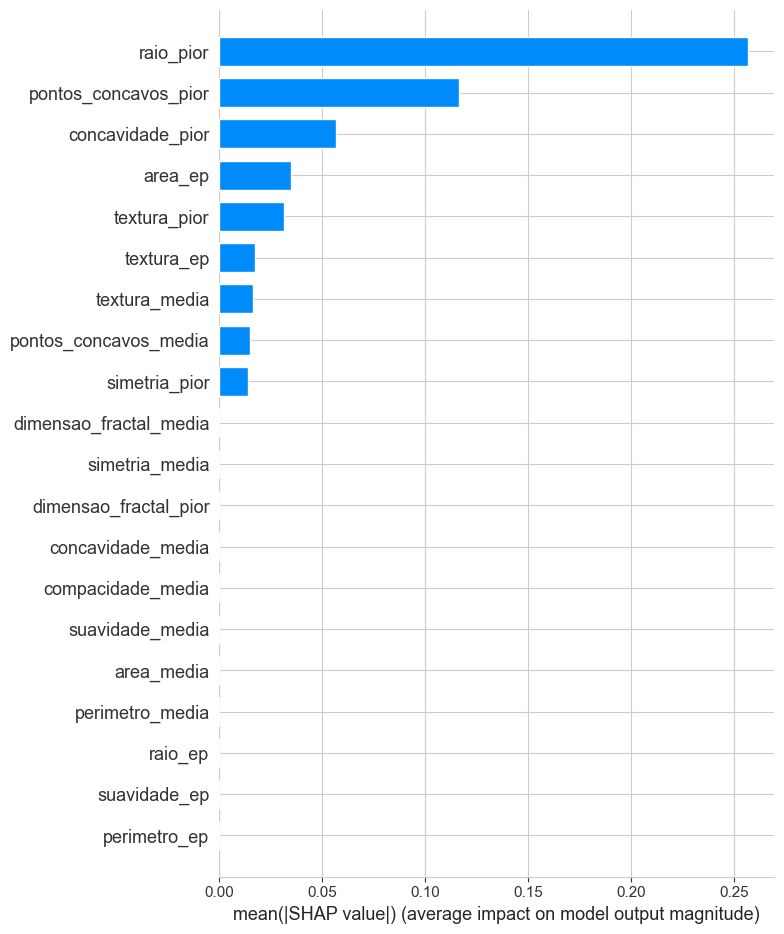

In [153]:
# ==========================================================
# 6.2 SHAP VALUES -
# ==========================================================

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ----------------------------------------------------------
# Garantir nomes corretos das features
# ----------------------------------------------------------
feature_names = X.columns.tolist()

# Converter conjunto de teste escalonado para DataFrame
X_teste_df = pd.DataFrame(
    X_teste_scaled,
    columns=feature_names
)

# ----------------------------------------------------------
# Criar explicador SHAP para Árvore de Decisão
# ----------------------------------------------------------
explainer = shap.TreeExplainer(modelo_arvore)

# Calcular valores SHAP
shap_values = explainer.shap_values(X_teste_df)

# ----------------------------------------------------------
# Compatibilidade entre versões do SHAP
# ----------------------------------------------------------
if isinstance(shap_values, list):
    # Algumas versões retornam lista por classe
    shap_values_plot = shap_values[1]

else:
    shap_array = np.array(shap_values)

    # Algumas versões retornam array 3D
    if len(shap_array.shape) == 3:
        shap_values_plot = shap_array[:, :, 1]
    else:
        shap_values_plot = shap_values

# ----------------------------------------------------------
# SUMMARY PLOT (Beeswarm)
# ----------------------------------------------------------
print("SHAP Summary Plot - Árvore de Decisão")

plt.figure(figsize=(12, 7))

shap.summary_plot(
    shap_values_plot,
    X_teste_df,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()

plt.savefig(
    os.path.join(DIR_RESULTADOS, "cm_shap_summary.png"),
    dpi=150,
    bbox_inches="tight"
)

print("-> Gráfico salvo em:", os.path.join(DIR_RESULTADOS, "cm_shap_summary.png"))

plt.show()

# ----------------------------------------------------------
# BAR PLOT (Importância média)
# ----------------------------------------------------------
print("SHAP Bar Plot - Importância Média")

plt.figure(figsize=(12, 7))

shap.summary_plot(
    shap_values_plot,
    X_teste_df,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    os.path.join(DIR_RESULTADOS, "cm_shap_bar.png"),
    dpi=150,
    bbox_inches="tight"
)

print("-> Gráfico salvo em:", os.path.join(DIR_RESULTADOS, "cm_shap_bar.png"))

plt.show()

SHAP Summary Plot - Regress?o Log?stica
-> Gr?fico salvo em: ..\resultados\cm_shap_summary_lr.png


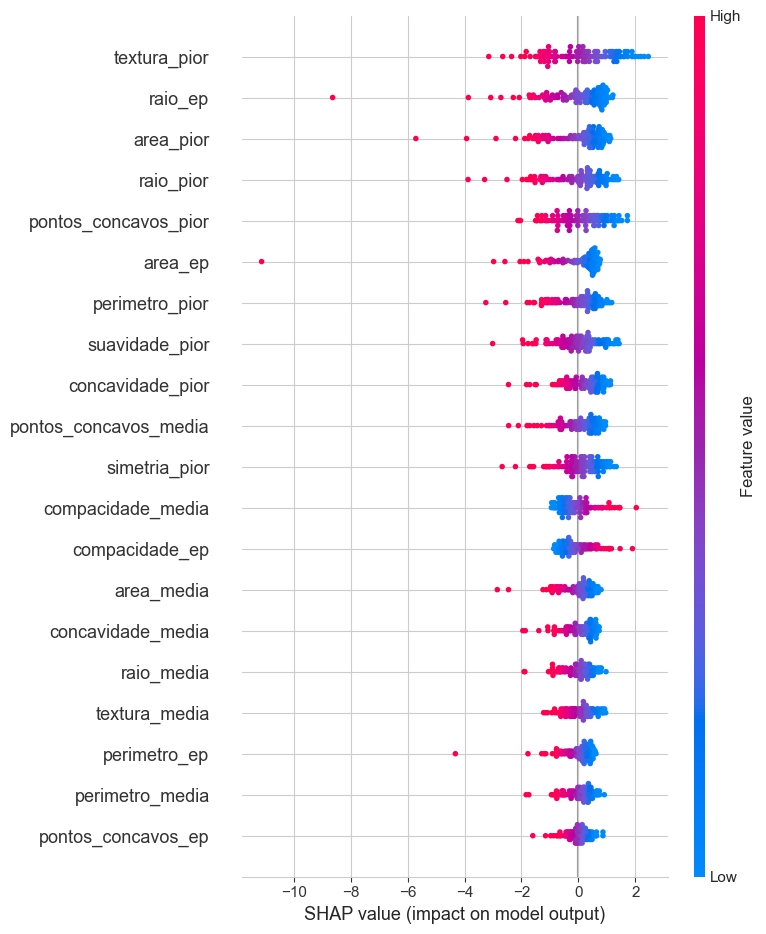

SHAP Bar Plot - Import?ncia M?dia
-> Gr?fico salvo em: ..\resultados\cm_shap_bar_lr.png


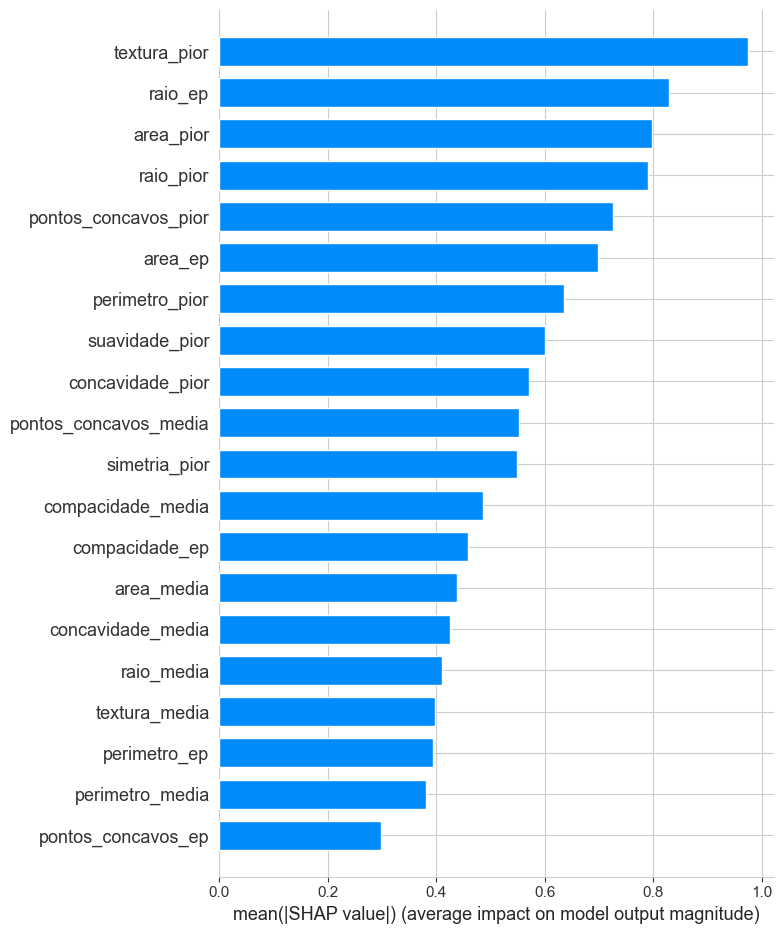

In [154]:
# ==========================================================
# 6.2 SHAP VALUES - REGRESS?O LOG?STICA
# ==========================================================

# ----------------------------------------------------------
# Garantir nomes corretos das features
# ----------------------------------------------------------
feature_names = X.columns.tolist()

# Converter conjuntos escalonados para DataFrame
X_treino_df = pd.DataFrame(X_treino_scaled, columns=feature_names)
X_teste_df = pd.DataFrame(X_teste_scaled, columns=feature_names)

# ----------------------------------------------------------
# Criar explicador SHAP para Regressao Logistica
# ----------------------------------------------------------
# Usamos um background amostrado do treino para deixar o SHAP mais rapido/estavel
background = shap.sample(X_treino_df, 200, random_state=42) if len(X_treino_df) > 200 else X_treino_df
explainer_lr = shap.LinearExplainer(modelo_lr, background)

# Calcular valores SHAP
shap_values_lr = explainer_lr.shap_values(X_teste_df)

# ----------------------------------------------------------
# Compatibilidade entre versoes do SHAP
# ----------------------------------------------------------
if isinstance(shap_values_lr, list):
    # Algumas versoes retornam lista por classe
    shap_values_lr_plot = shap_values_lr[1] if len(shap_values_lr) > 1 else shap_values_lr[0]
else:
    shap_values_lr_plot = shap_values_lr

# ----------------------------------------------------------
# SUMMARY PLOT (Beeswarm)
# ----------------------------------------------------------
print("SHAP Summary Plot - Regressao Logistica")

plt.figure(figsize=(12, 7))

shap.summary_plot(
    shap_values_lr_plot,
    X_teste_df,
    feature_names=feature_names,
    color=plt.get_cmap("RdBu"),
    show=False
)
plt.gcf().patch.set_facecolor('white')
plt.gca().set_facecolor('white')

plt.tight_layout()

plt.savefig(
    os.path.join(DIR_RESULTADOS, 'cm_shap_summary_lr.png'),
    dpi=150,
    bbox_inches='tight'
)

print('-> Grafico salvo em:', os.path.join(DIR_RESULTADOS, 'cm_shap_summary_lr.png'))

plt.show()

# ----------------------------------------------------------
# BAR PLOT (Importancia media)
# ----------------------------------------------------------
print("SHAP Bar Plot - Importancia Media")

plt.figure(figsize=(12, 7))

shap.summary_plot(
    shap_values_lr_plot,
    X_teste_df,
    feature_names=feature_names,
    plot_type='bar',
    show=False
)
plt.gcf().patch.set_facecolor('white')
plt.gca().set_facecolor('white')

plt.tight_layout()

plt.savefig(
    os.path.join(DIR_RESULTADOS, 'cm_shap_bar_lr.png'),
    dpi=150,
    bbox_inches='tight'
)

print('-> Gr?fico salvo em:', os.path.join(DIR_RESULTADOS, 'cm_shap_bar_lr.png'))

plt.show()


# 7. Discussão Crítica

## O modelo pode ser aplicado como ferramenta de apoio na prática clínica?

Os modelos desenvolvidos apresentaram resultados positivos nas métricas de avaliação, com destaque para a Regressão Logística, que obteve o melhor desempenho geral, seguida de perto pelo KNN.

Esses resultados indicam que técnicas de Machine Learning possuem potencial para auxiliar na identificação precoce de casos suspeitos de câncer de mama.

No entanto, é importante destacar que este trabalho possui caráter **acadêmico e experimental**, tendo como objetivo aplicar conceitos estudados ao longo da pós-graduação. Dessa forma, os resultados obtidos servem para fins educacionais e de demonstração técnica.

---

## Pontos fortes observados

- Alto desempenho geral nas métricas de classificação;
- Bons índices de recall, importantes para reduzir casos malignos não detectados;
- Capacidade de identificar variáveis relevantes para o diagnóstico;
- Processamento rápido, podendo apoiar triagens iniciais;
- Possibilidade de uso como segunda opinião automatizada.

---

## Limitações identificadas

Apesar dos bons resultados, algumas limitações precisam ser consideradas:

- O dataset utilizado possui tamanho relativamente reduzido (569 amostras);
- Trata-se de uma base estruturada e limpa, diferente da realidade de muitos hospitais;
- O modelo foi treinado em dados históricos específicos, podendo perder desempenho em novos contextos;
- Não houve validação externa com dados de outras instituições;
- O sistema trabalha apenas com variáveis numéricas, sem analisar imagens diretamente.

Além disso, pela quantidade limitada de dados utilizada neste projeto, o modelo **não deve ser considerado adequado para uso em decisões clínicas reais**, pois sistemas aplicados na prática médica exigem bases muito maiores, diversidade populacional, validação multicêntrica e acompanhamento contínuo de desempenho.

---

## Risco dos erros de classificação

Em aplicações médicas, não basta observar apenas a acurácia.

Erros do tipo falso negativo, onde um caso maligno é classificado como benigno, podem atrasar diagnósticos e comprometer o tratamento. Por isso, métricas como recall e sensibilidade se tornam especialmente importantes.

---

## O papel do médico

Mesmo com bons resultados, a decisão final nunca deve ser delegada exclusivamente ao modelo.

A Inteligência Artificial deve ser utilizada como ferramenta de apoio ao profissional de saúde, contribuindo para:

- Priorização de exames suspeitos;
- Apoio na triagem inicial;
- Identificação de padrões relevantes;
- Segunda opinião baseada em dados.

A interpretação clínica, histórico do paciente e demais exames continuam sendo responsabilidade do médico.

---

## Considerações finais

De forma geral, o projeto mostrou que modelos relativamente simples podem alcançar excelente desempenho nesse problema específico.

Entretanto, por se tratar de um estudo acadêmico com base limitada, os resultados não devem ser extrapolados diretamente para ambientes hospitalares reais.

Para uma aplicação prática, seriam necessários novos testes, bases de dados maiores e mais diversas, validação externa, monitoramento contínuo e integração com especialistas da área médica.

Assim, a IA se mostra promissora como apoio ao diagnóstico, mas não como substituição da decisão humana.